# Topic: Analyzing the Dark Matter Halo Shape of M33 

### Question: How does the ellipticity of M33's DM halo shape change over time 

### Output Plots: Triaxiality versus time of M33's halo taken at R200, R200/2, and R200/4, DM particle density projections near time of M31-MW merger

In [2]:
# Nicolas Mazziotti

# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.image as mpimg

# some of my code takes a while, so use tqdm to see progress
from tqdm import tqdm

# my modules
from ReadFile import Read
from CenterOfMass import CenterOfMass
from MassProfile import MassProfile

# module I created
from HaloShape import HaloShape

# for ellipse fitting 
from photutils.isophote import Ellipse, EllipseGeometry

# Create DM Density Projections At Every 10 Snapshots

In [4]:
def RunEllipseFitting(axis1, axis2):
    """
    Function that fits isodensity contours to a specific projection of the M33 DM particle density. 
    Fitting is performed at every 10 snapshots in the full 800 snapshot range of the simulation. 

    INPUTS:
        - axis1 (int): Axis to project along the vertical axis (x = 0, y = 1, z = 2)
        - axis2 (int): Axis to project along the horizontal axis (x = 0, y = 1, z = 2)

    OUTPUTS:
        - table_info (numpy aray): Array of ellipse information extracted at R200, R200/2, and R200/4. Failed snaps will 
            have an array value of 1.
        - fit_success (numpy array): Boolean array of the snapshots where the ellipse fitting was successful. 
    """
    
    snap_range = np.arange(0, 799, 10) # Read in every 10 snapshots 
    fit_success = np.ones(len(snap_range), dtype=bool) # Initialize fitting result as successful for all snapshots
    table_info = np.ones(len(snap_range), dtype=tuple) # Store ellipse information to this array to create table from later on

    # Looping through every 10 snapshots (tqdm to see progress)
    for i in tqdm(range(len(snap_range))):
        snap = snap_range[i]
        
        # Create HaloShape object at given snap (see HaloShape.py)
        M33 = HaloShape('M33', snap)
    
        # See if ellipse fitting works on first try
        try:
            # Retrieve fitting of all ellipses, and then the ellipticity, position angle, semimajor axis (a) in kpc, and semiminor axis (b)
            # in kpc at R200, R200/2, and R200/4
            isophotes, eps, pa, sma, smb = M33.PlotEllipses(axis1, axis2) 
    
            # Save the snapshot time (Myr), and the ellipse information at R200, R200/2, and R200/4 to a row for our table
            row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)
            table_info[i] = row 
    
        # If the ellipse fitting fails it will raise a ValueError
        except ValueError:
            # Try again but with smaller initial semimajor axis guess of 5 pixels (default is 10 pixels)
            try:
                isophotes, eps, pa, sma, smb = M33.PlotEllipses(axis1, axis2, sma=5)

                # If this try is successful, store to table_info 
                row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)
                table_info[i] = row 
    
            # If fails again, set index corresponding to this snapshot in fitting_success to False
            except ValueError:  
                fit_success[i] = False

    # Return results of fitting algorithm 
    return table_info, fit_success

def SaveToTable(axis1, axis2, table_info, fit_success):
    """
    Function that extracts the ellipse information from the successful snapshots from RunEllipseFitting and stores 
    this data to a text file 

    INPUTS:
        - axis1 (int): Use same axis1 (x = 0, y = 1, z = 2) as what was used in RunEllipseFitting
        - axis2 (int): Use same axis2 (x = 0, y = 1, z = 2) as what was used in RunEllipseFitting
        - table_info (numpy array): Array of ellipse information extracted at R200, R200/2, and R200/4. Failed snaps will 
            have an array value of 1. 
        - fit_success (numpy array): Boolean array of the snapshots where the ellipse fitting was successful. Will be used to filter 
            table_info. 

    OUTPUTS:
        Saves ellipse data form successful snapshots to a file named "halo_evo_{axis1}{axis2}.txt" in current directory. 
    """

    # Use True values from fit_success to filter out all rows of table_info that are set to 1 (failed snapshots)
    # ellipse data stored as tuples so need to first convert to list and then back to numpy array 
    table_data = np.array(table_info[fit_success].tolist())

    # Save to table with the following columns:
    # (0) t: snapshot time in Myr 
    # (1) r200_eps: ellipticity of r200 contour 
    # (2) r200/2_eps: ellipticity of r200/2 contour 
    # (3) r200/4_eps: ellipticity of r200/4 contour
    # (4) r200_pa: position angle of r200 contour in radians 
    # (5) r200/2_pa: position angle of r200/2 contour in radians 
    # (6) r200/4_pa: position angle of r200/4 contour in radians 
    # (7) r200_sma: semimajor axis of r200 contour in kpc (close to r200) 
    # (8) r200/2_sma: semimajor axis of r200/2 contour in kpc (close to r200/2)
    # (9) r200/4_sma: semimajor axis of r200/4 contour in kpc (close to r200/4)
    # (10) r200_smb: semiminor axis of r200 contour in kpc 
    # (11) r200/2_smb: semiminor axis of r200/2 contour in kpc 
    # (12) r200/4_smb: semiminor axis of r200/4 contour in kpc
    
    np.savetxt(f'halo_evo_{axis1}{axis2}.txt', table_data, fmt = "%11.3f"*13, comments='#',
                   header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                          .format('t', 'r200_eps', 'r200/2_eps', 'r200/4_eps', 
                                  'r200_pa', 'r200/2_pa', 'r200/4_pa',
                                 'r200_sma', 'r200/2_sma', 'r200/4_sma',
                                 'r200_smb', 'r200/2_smb', 'r200/4_smb'))

/home/nmazziotti/.local/lib/python3.8/site-packages/photutils/isophote/fitter.py:317: RuntimeWarning: invalid value encountered in double_scalars
  aux = -harmonic * (1.0 - sample.geometry.eps) / sample.gradient
/home/nmazziotti/astr_400b/ResearchAssignments/ResearchAssignment7/HaloShape.py:200: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax= plt.subplots(figsize=(12, 10))
/home/nmazziotti/astr_400b/ResearchAssignments/ResearchAssignment7/HaloShape.py:260: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warni

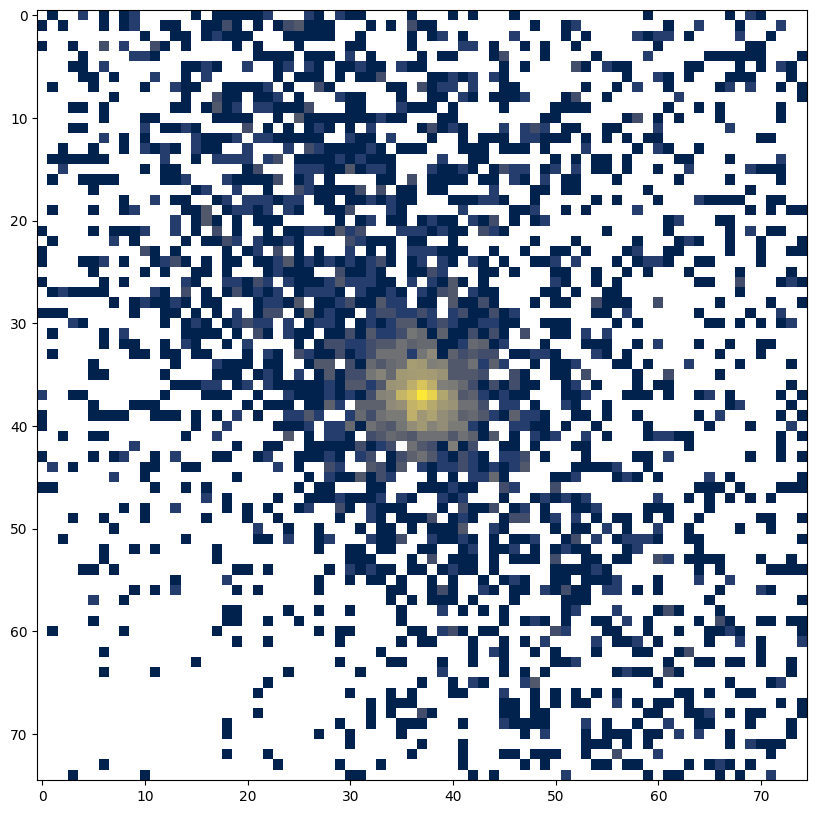

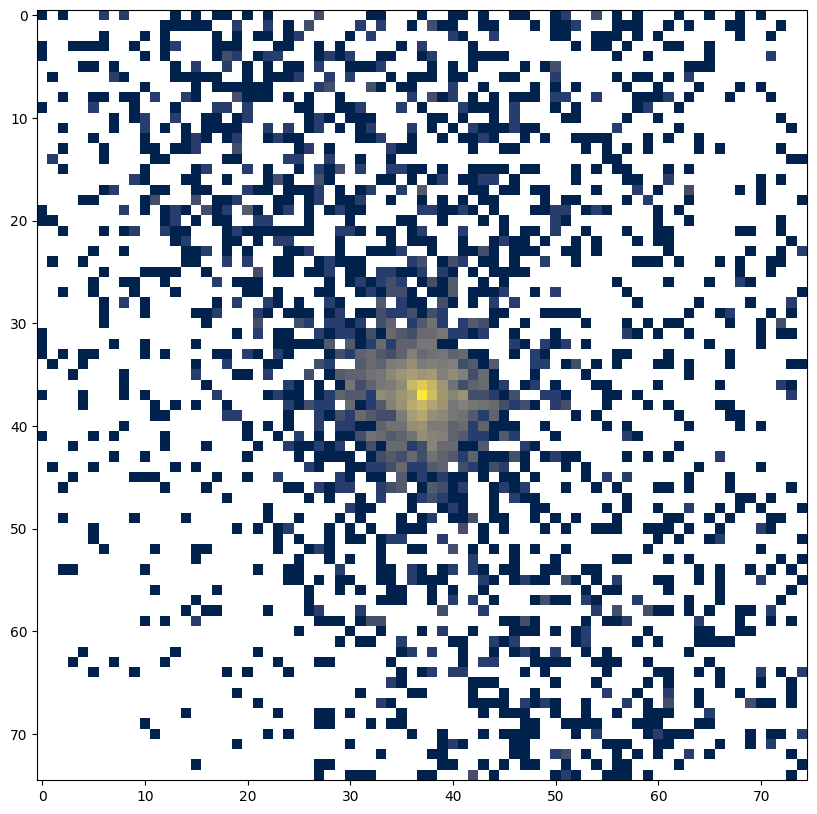

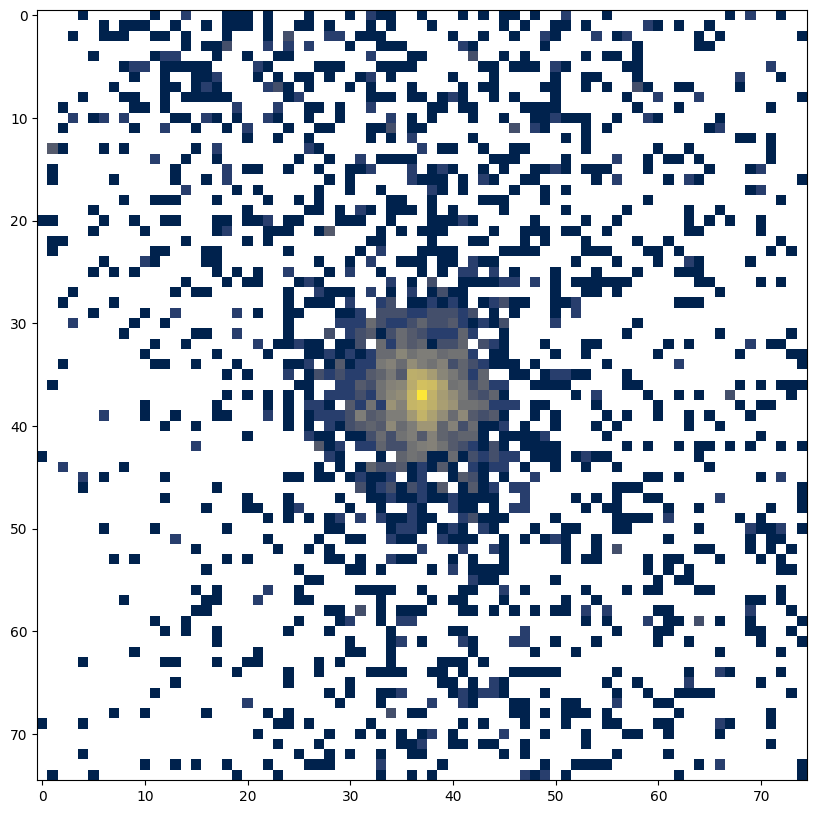

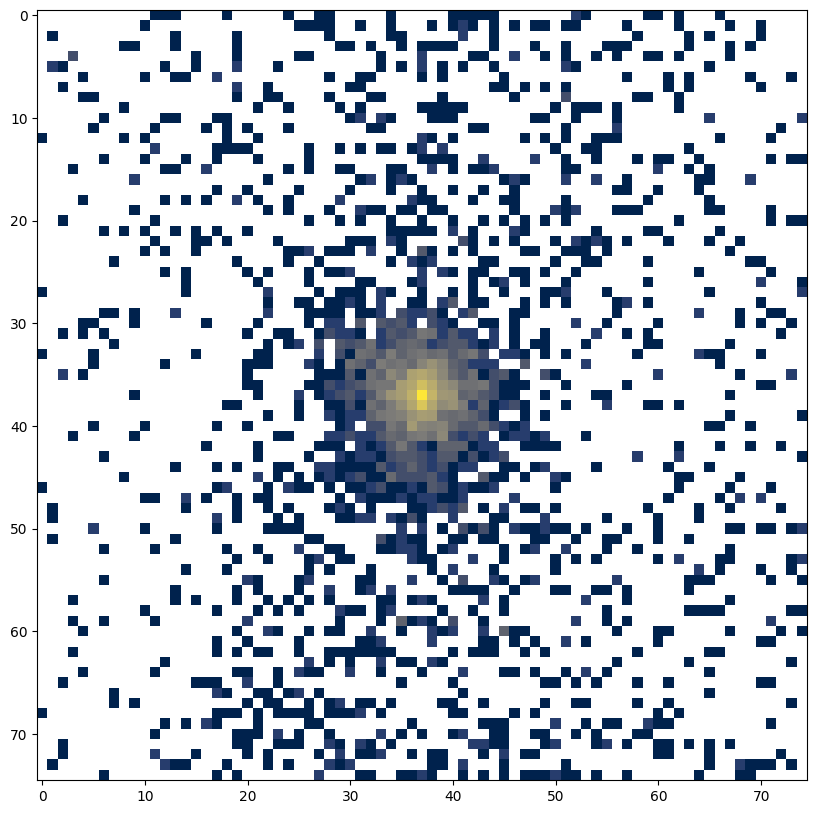

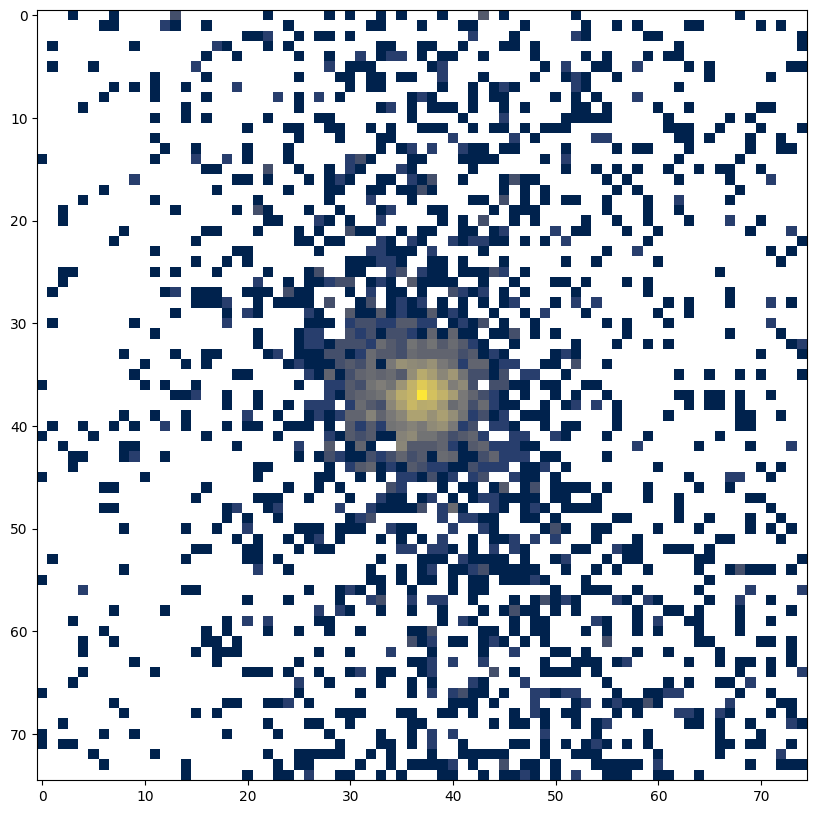

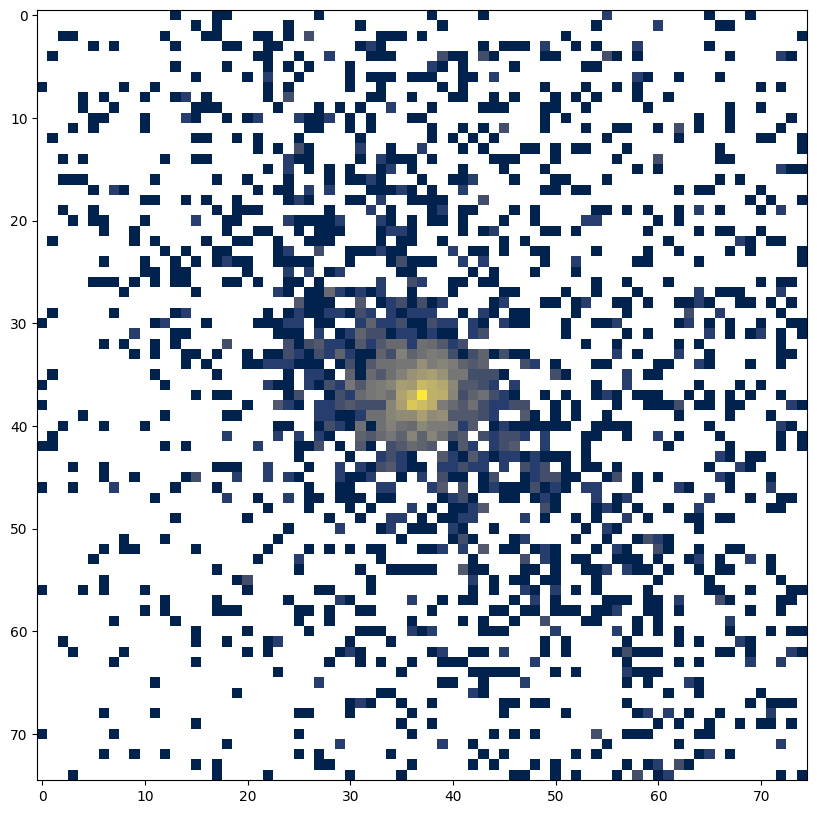

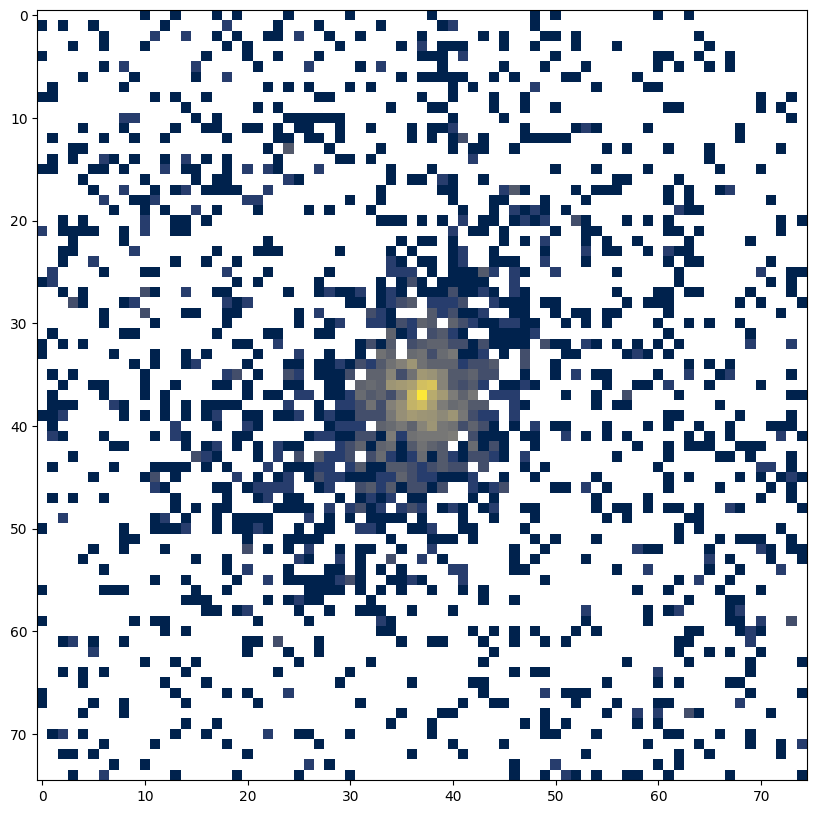

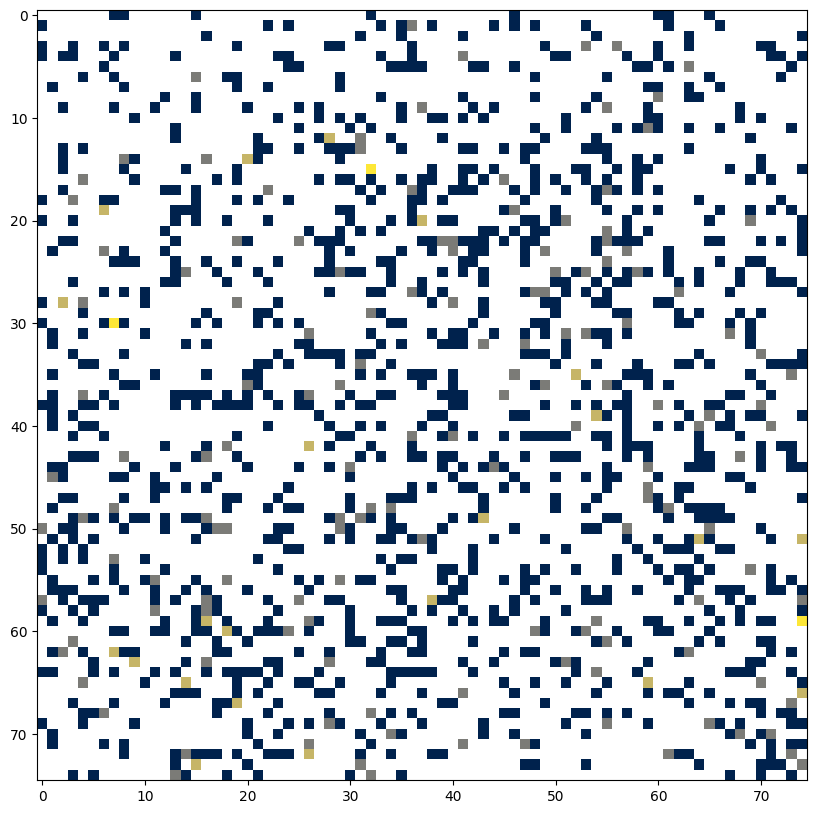

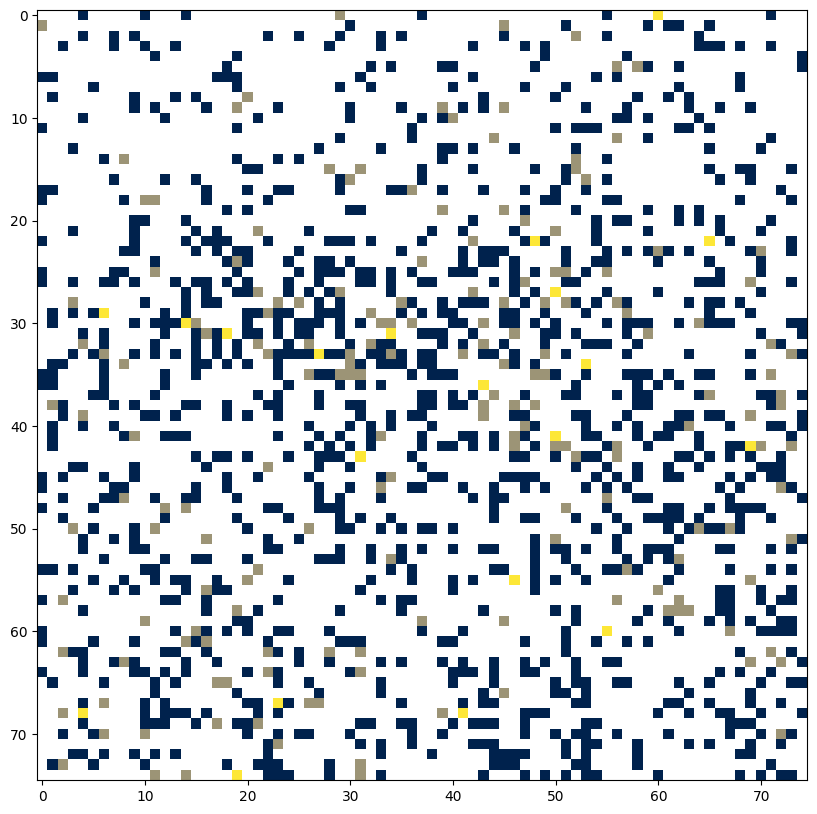

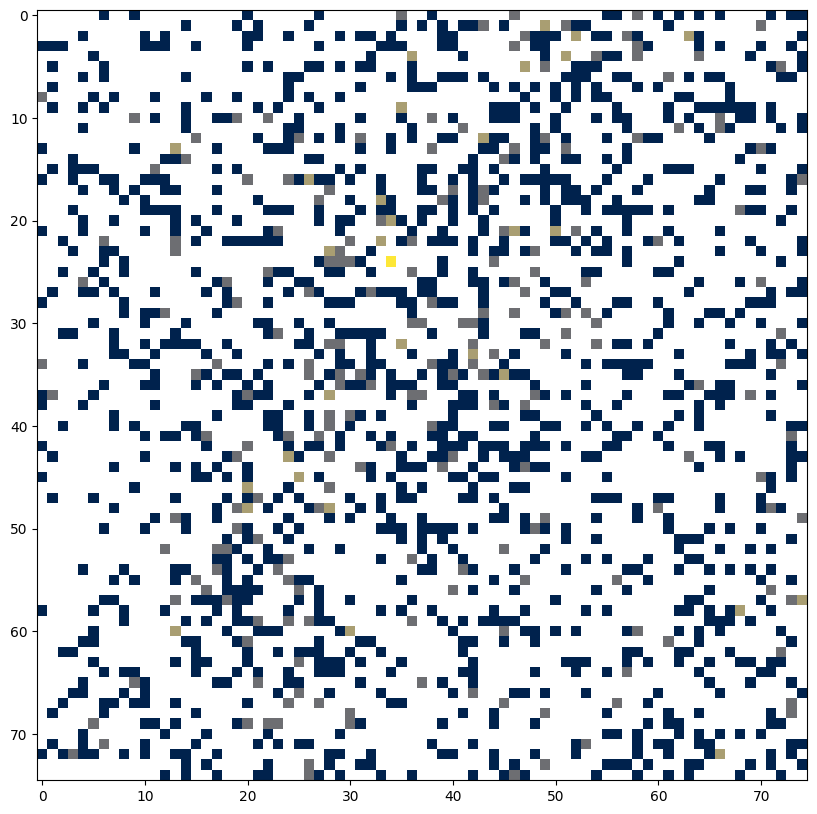

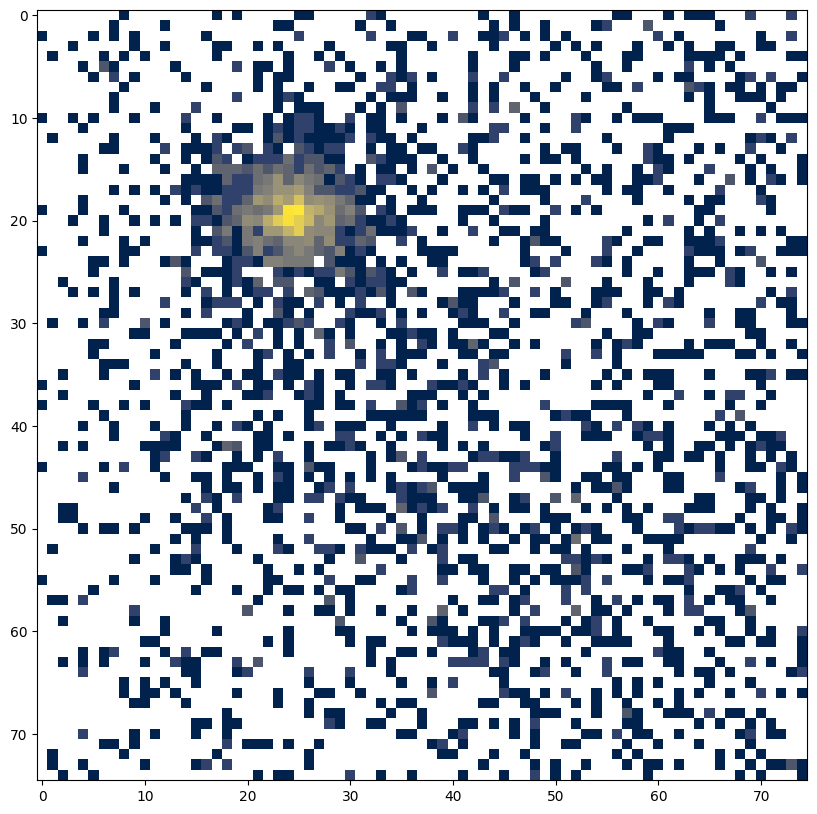

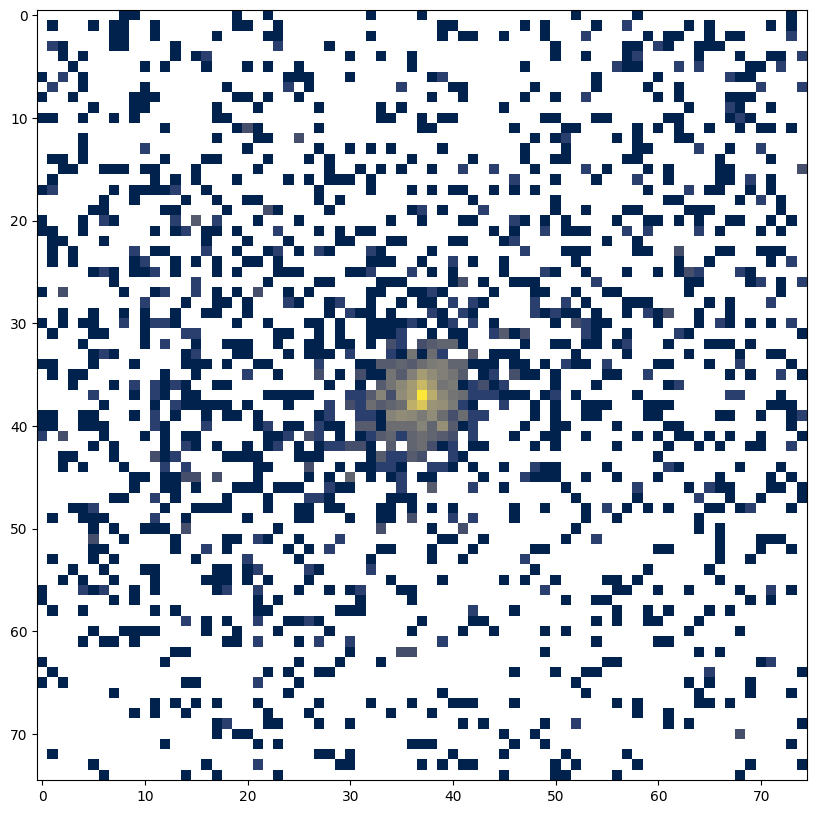

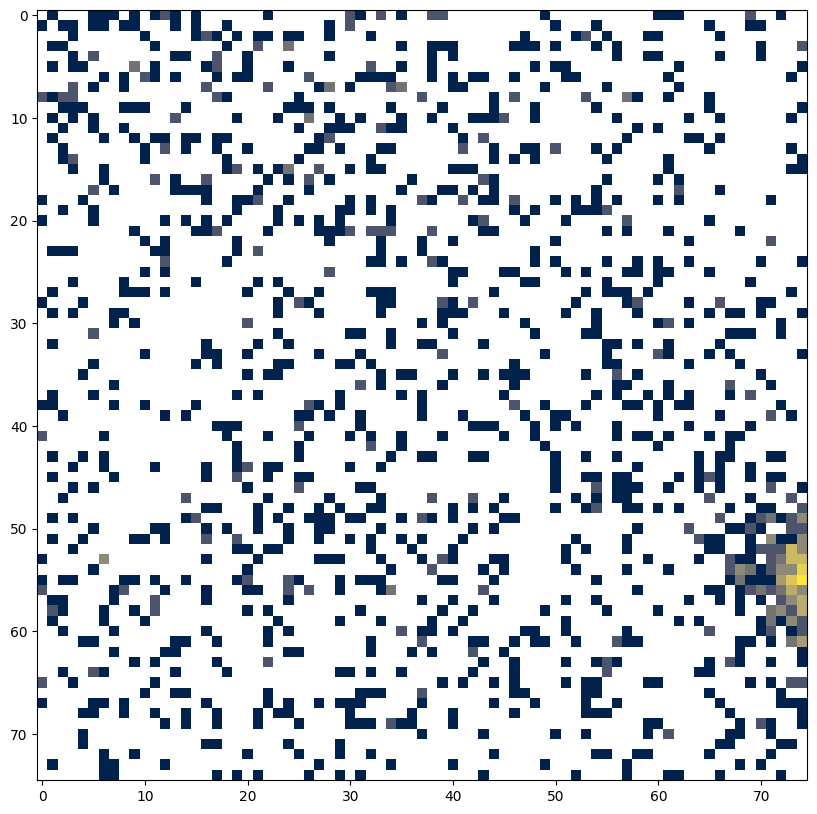

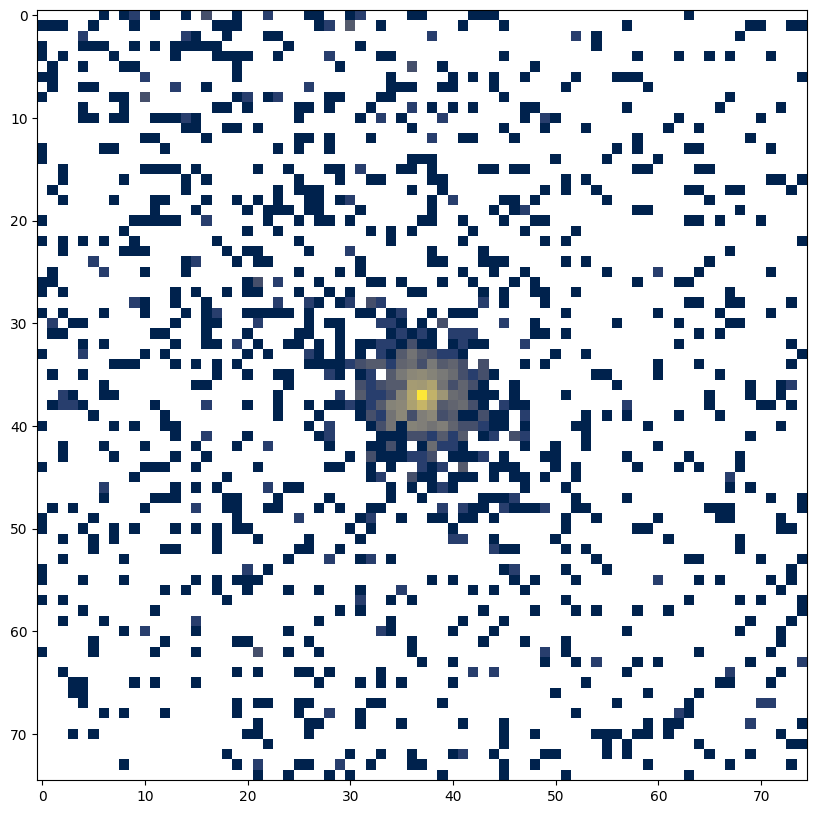

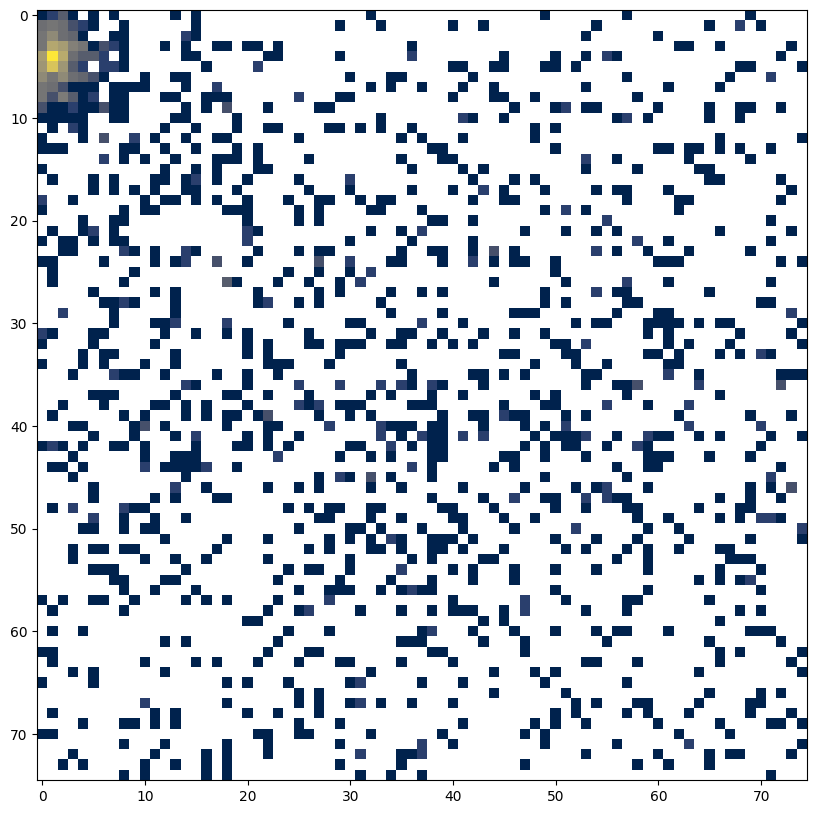

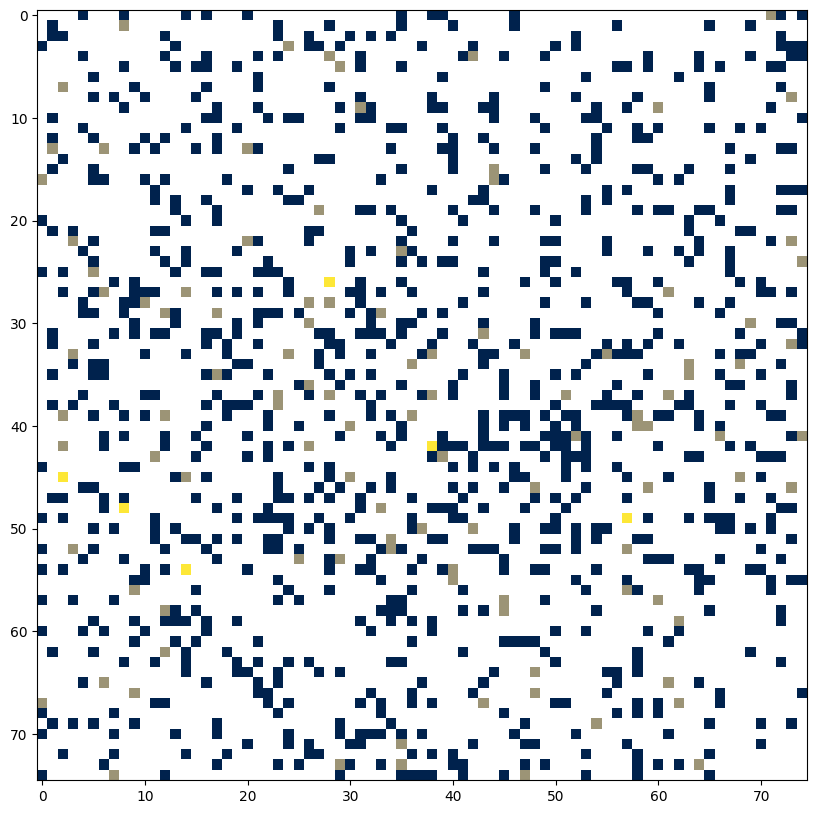

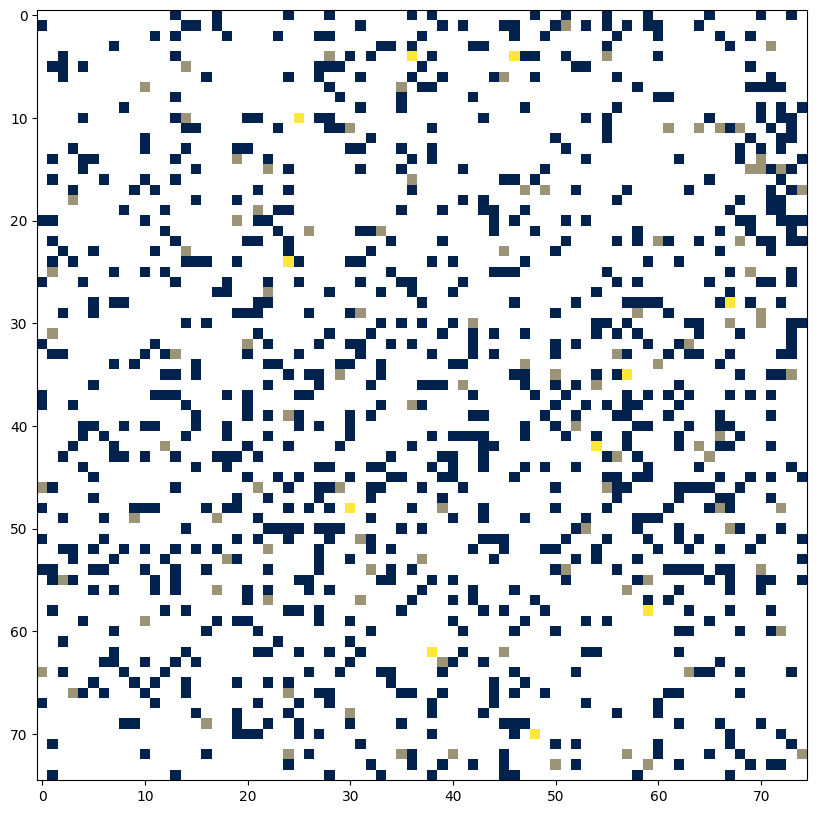

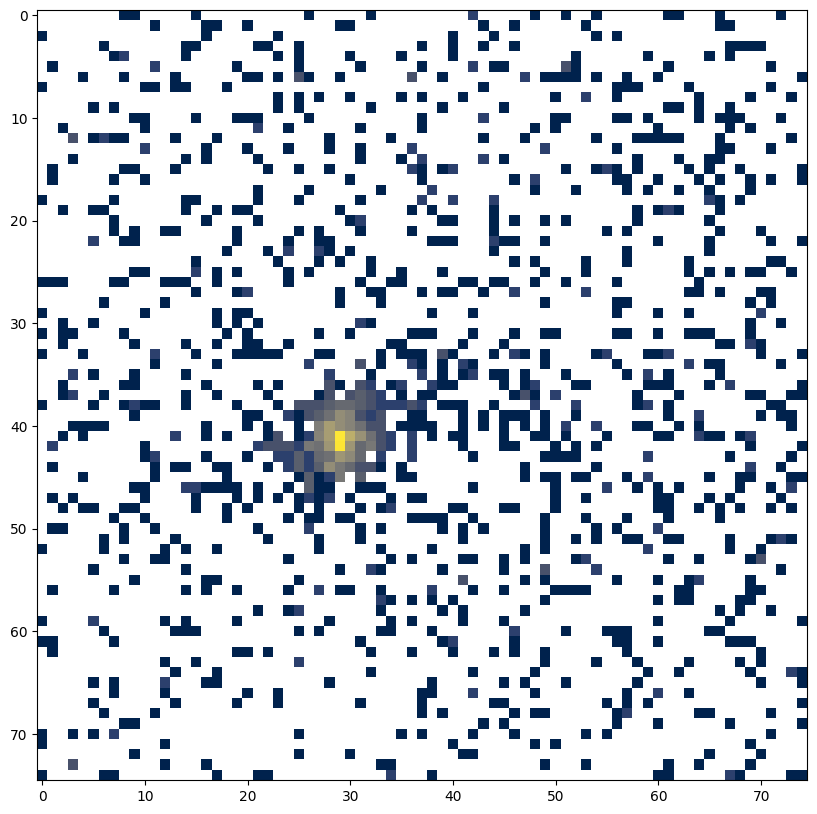

In [13]:
# Run ellipse fitting for x-y (01) projection
# Same as face-on projection of M33 

table_info_01, fit_success_01 = RunEllipseFitting(0, 1);
SaveToTable(0, 1, table_info_01, fit_success_01)

# Not sure why some plots are still shown here, I tried using plt.close() in HaloShape.py but it doesn't seem to always work 
# So please ignore the output plots shown in this notebook for this cell and the next two

100%|███████████████████████████████████████████| 80/80 [11:36<00:00,  8.70s/it]


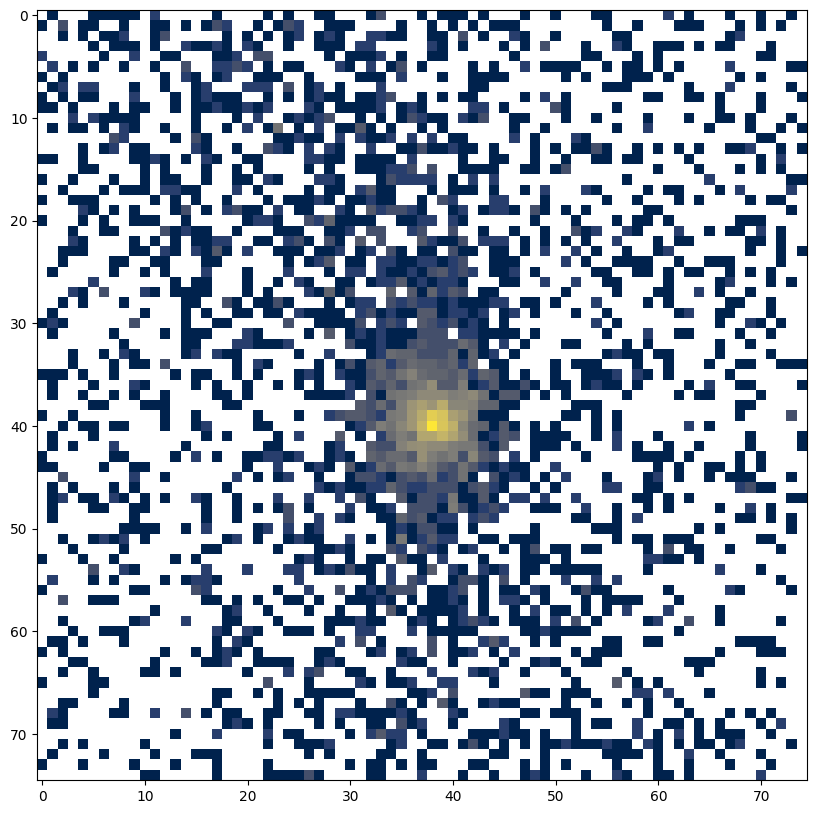

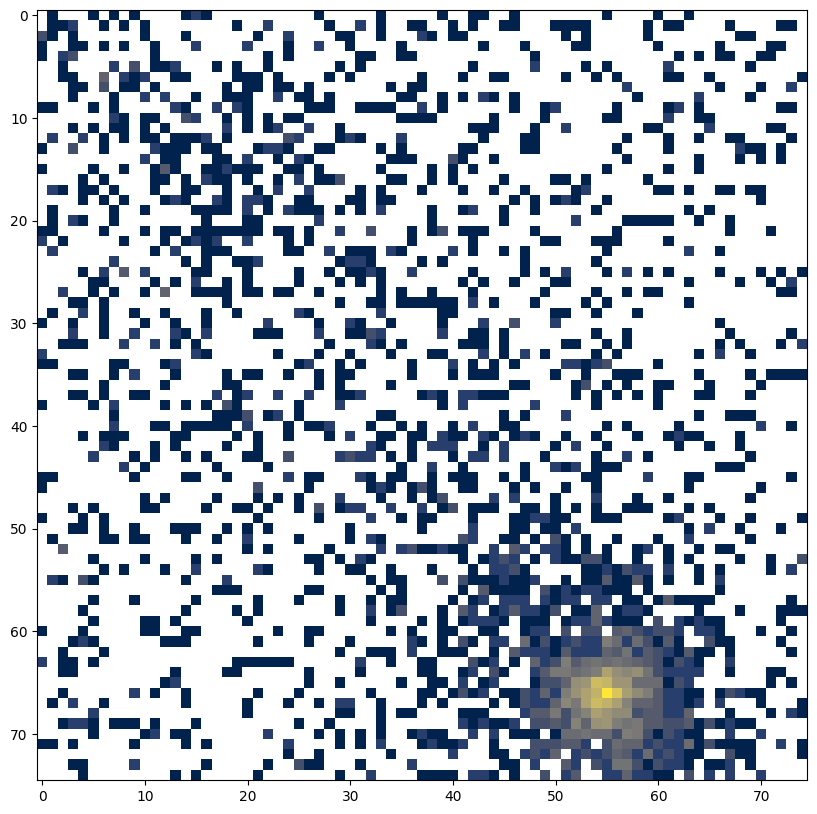

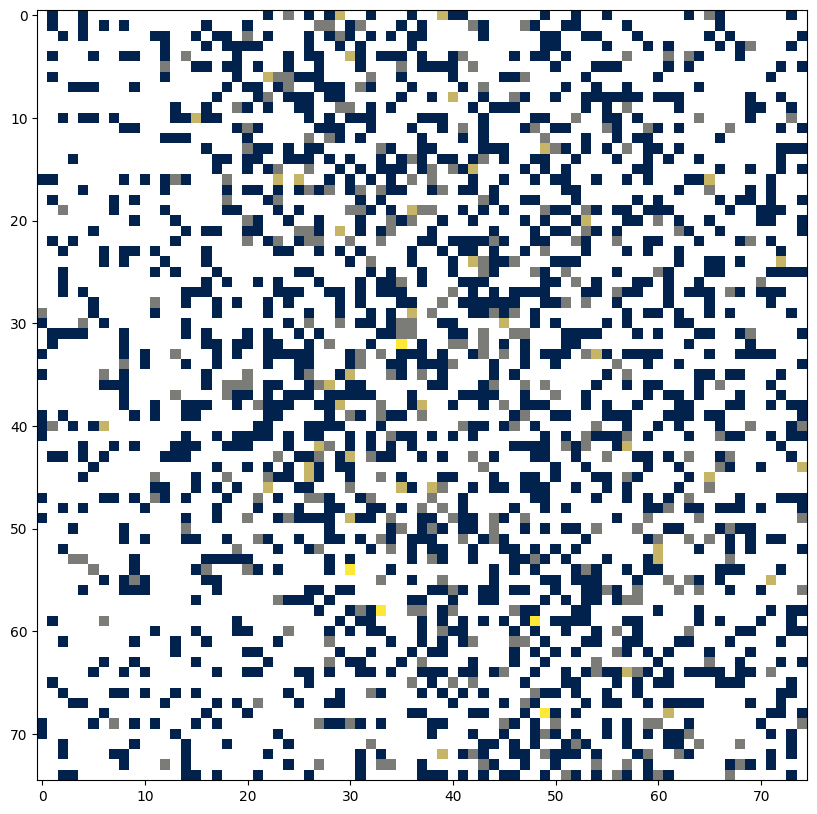

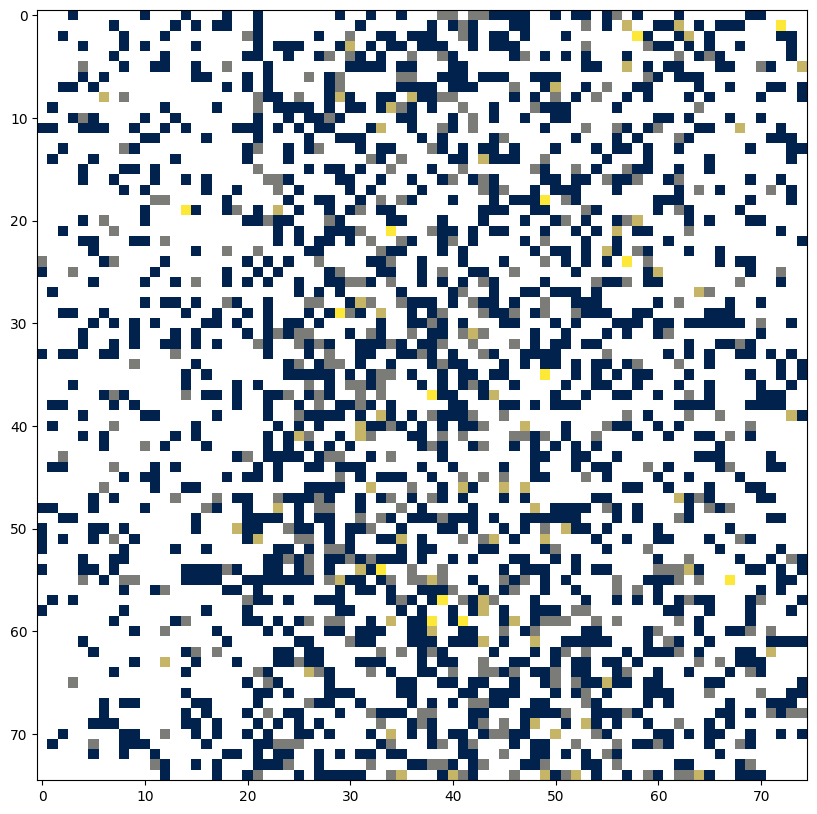

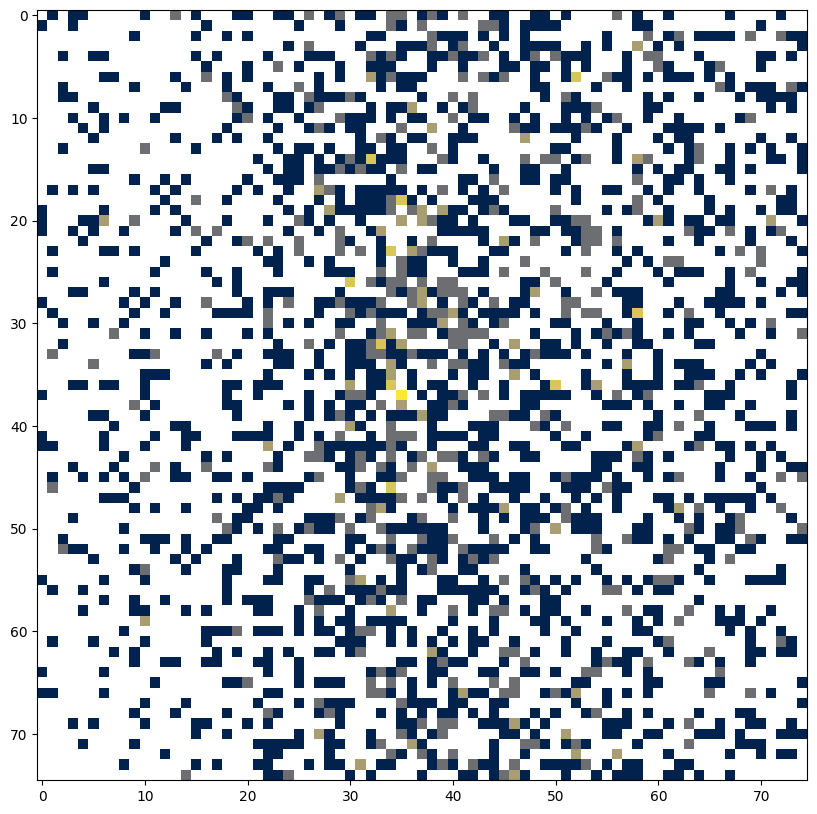

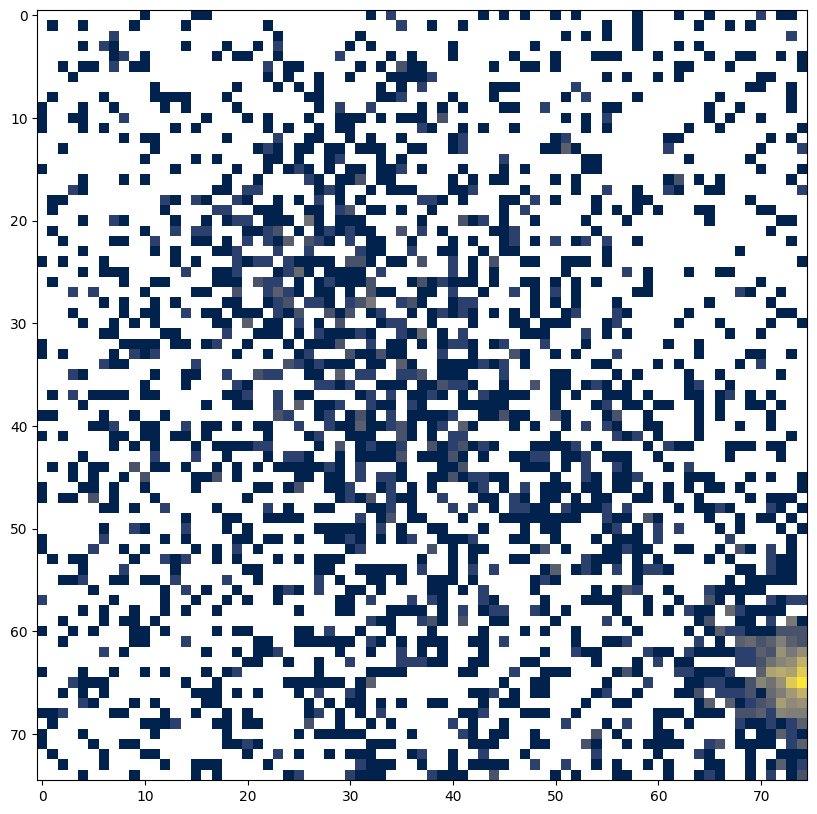

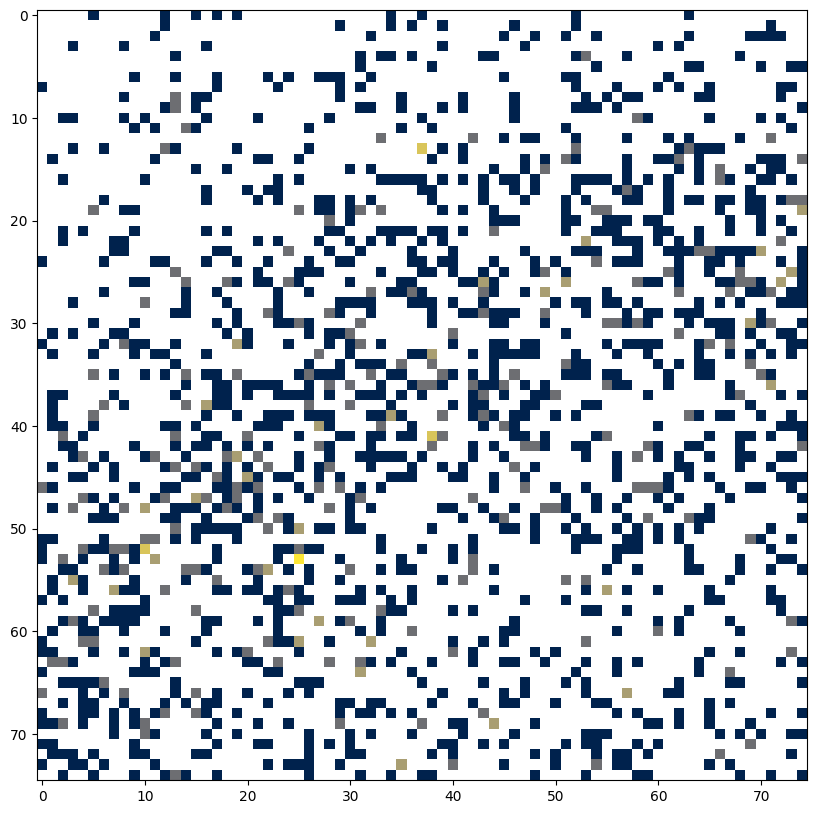

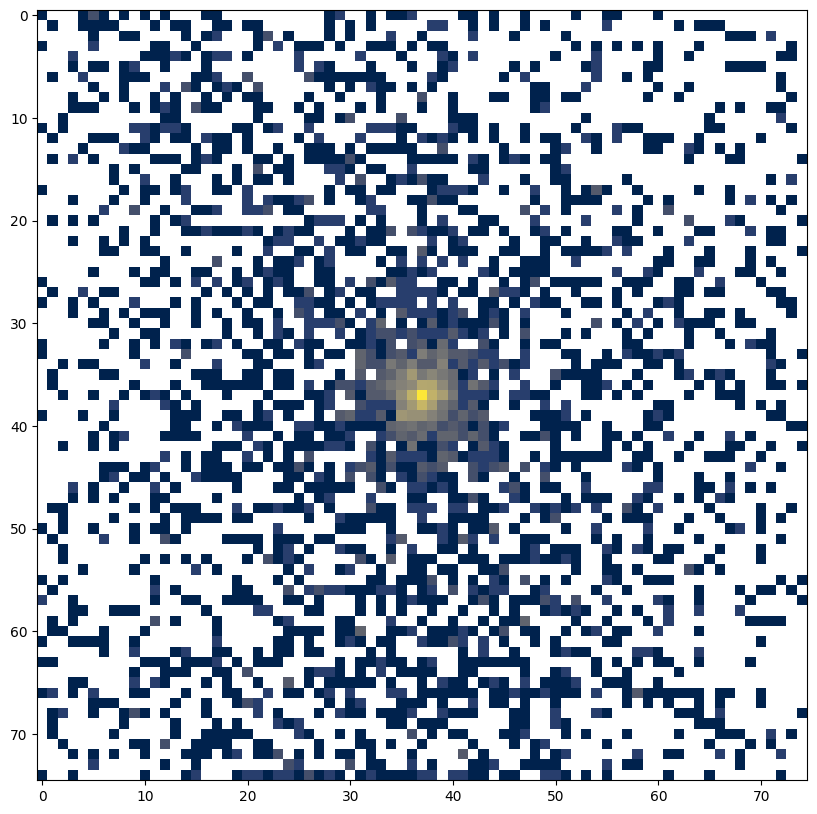

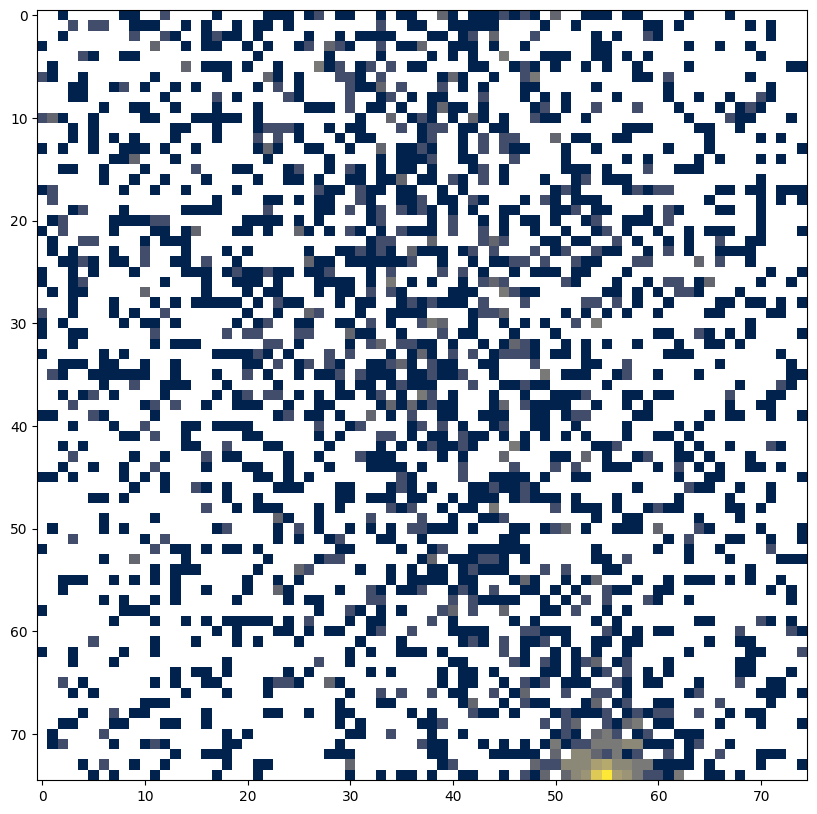

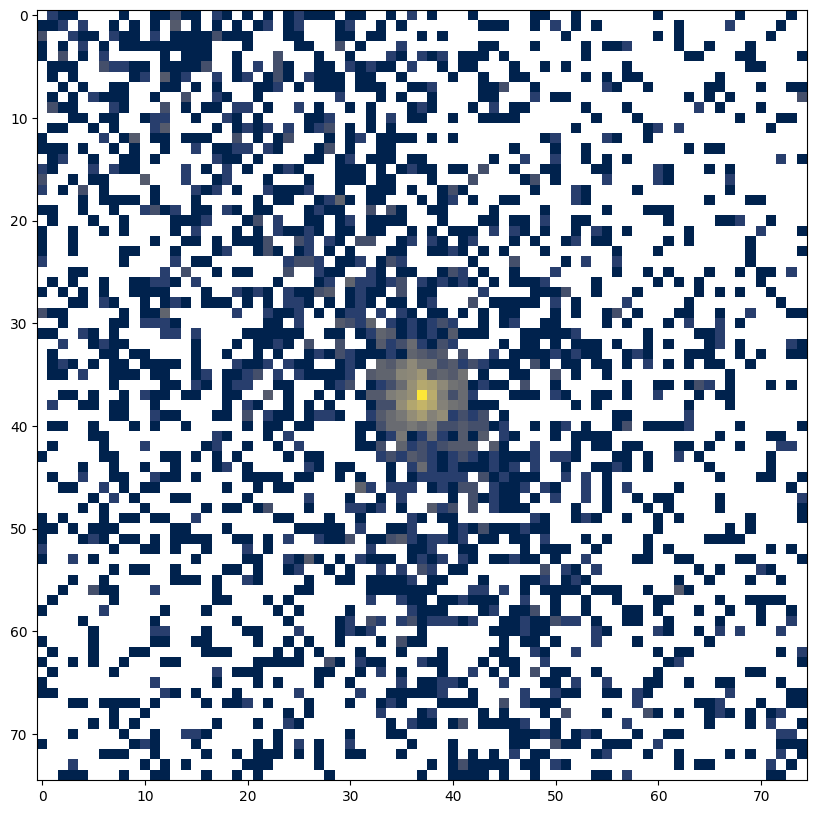

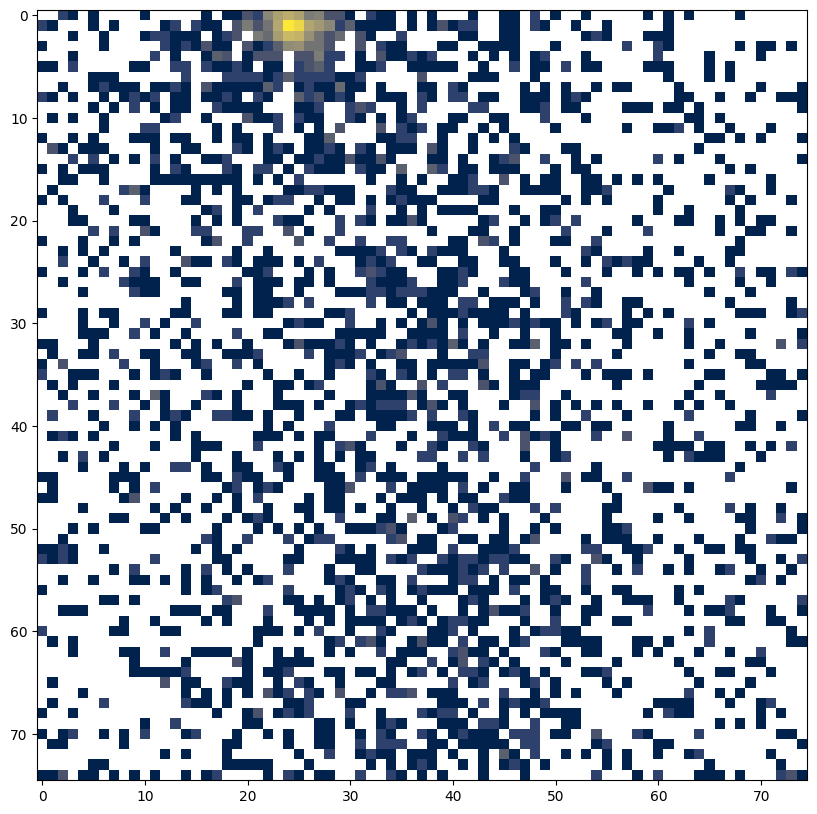

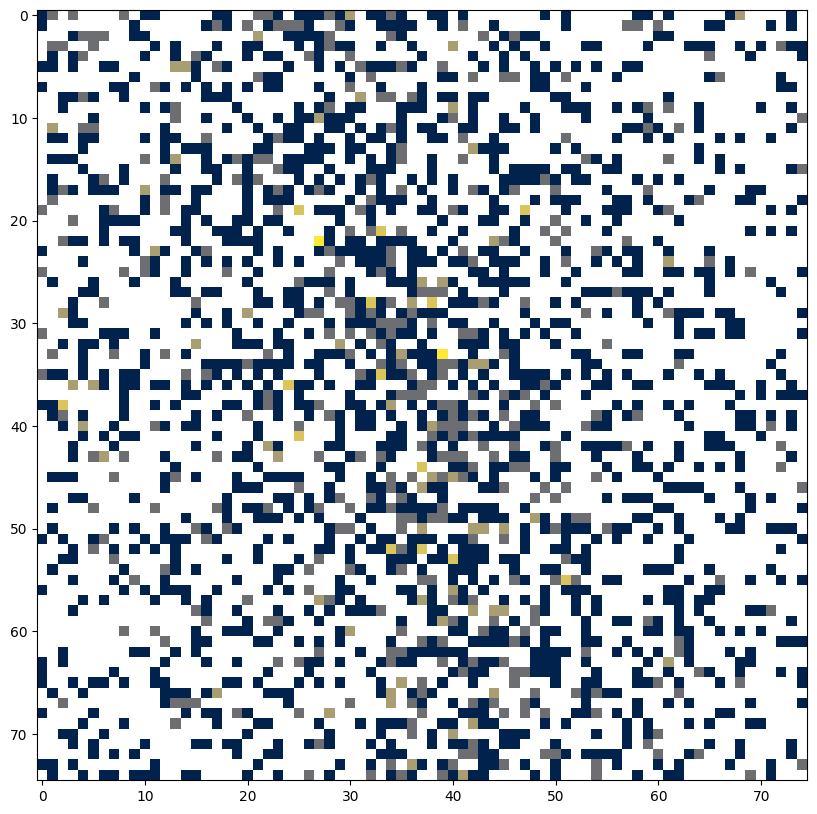

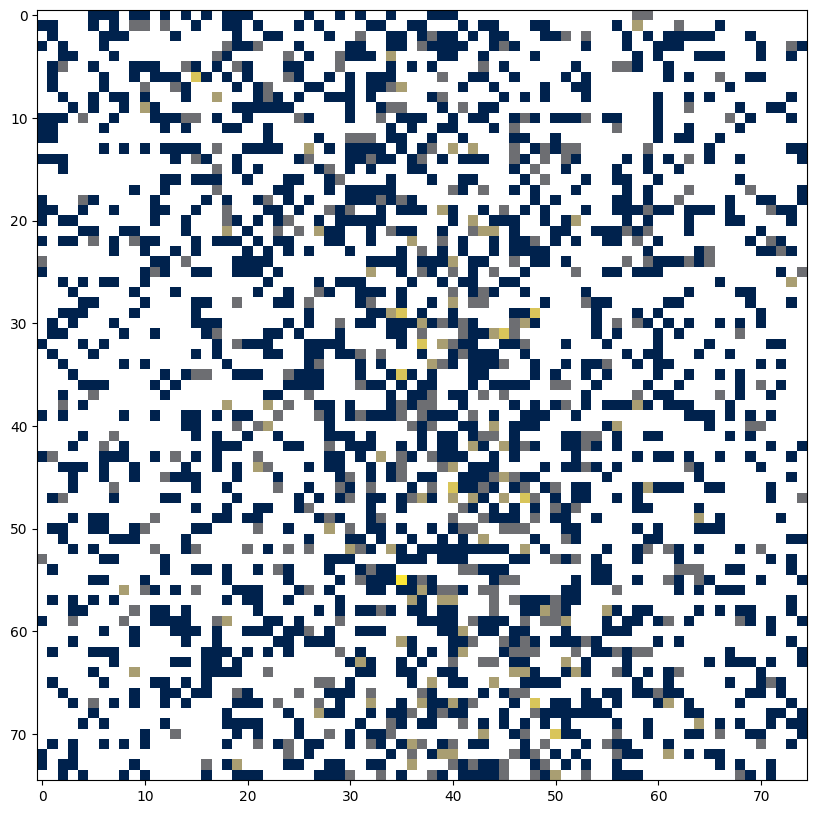

In [12]:
# Run ellipse fitting for y-z (12) projection
# Same as edge-on projection of M33 

table_info_12, fit_success_12 = RunEllipseFitting(1, 2);
SaveToTable(1, 2, table_info_12, fit_success_12)

/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
100%|███████████████████████████████████████████| 80/80 [11:48<00:00,  8.86

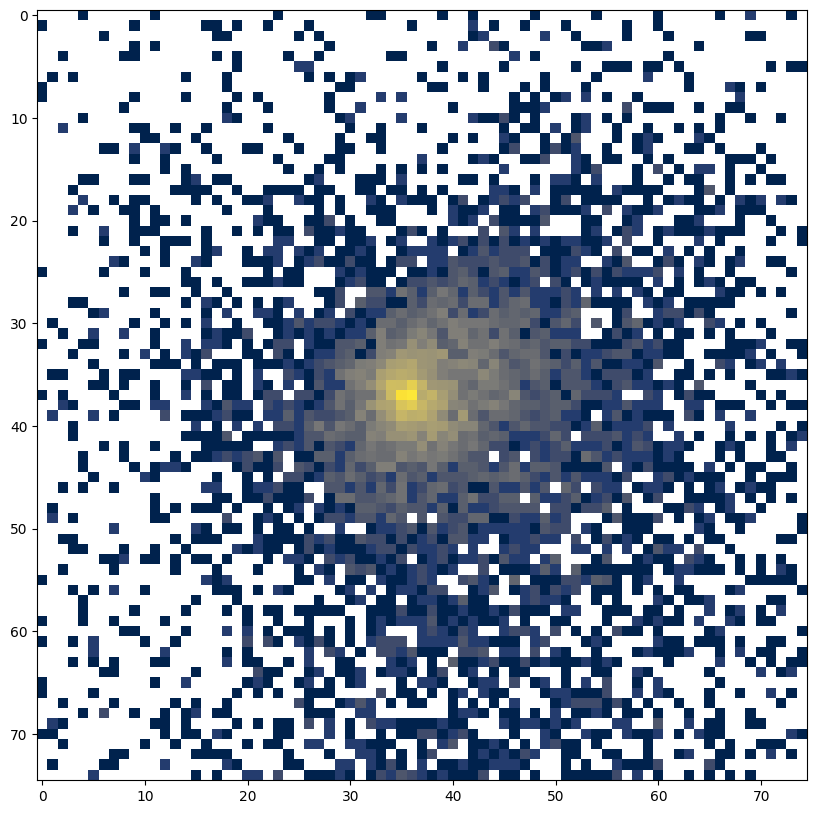

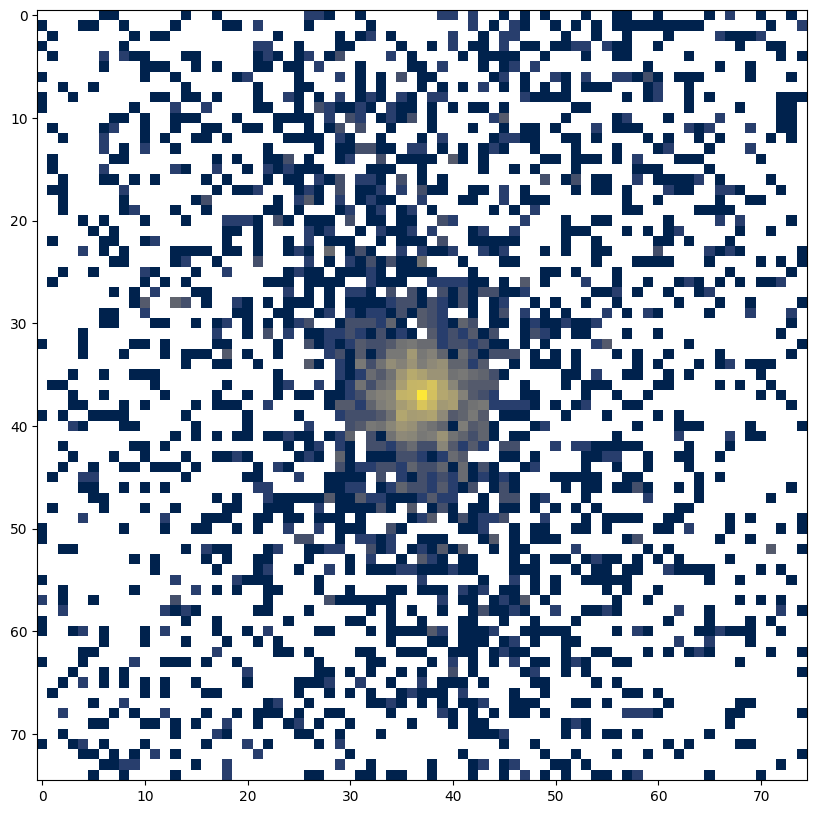

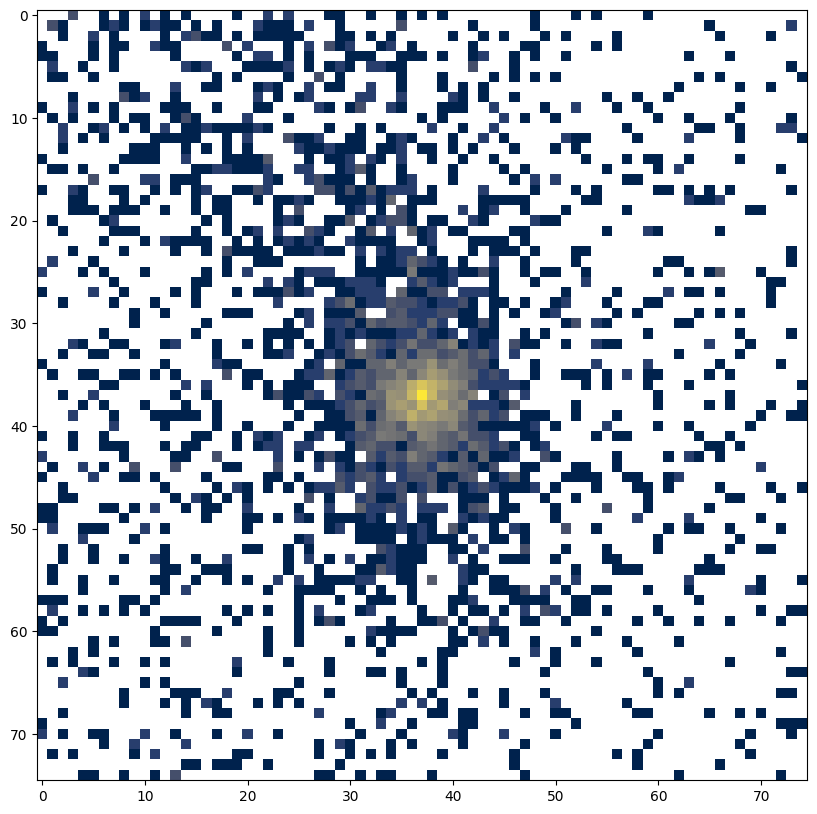

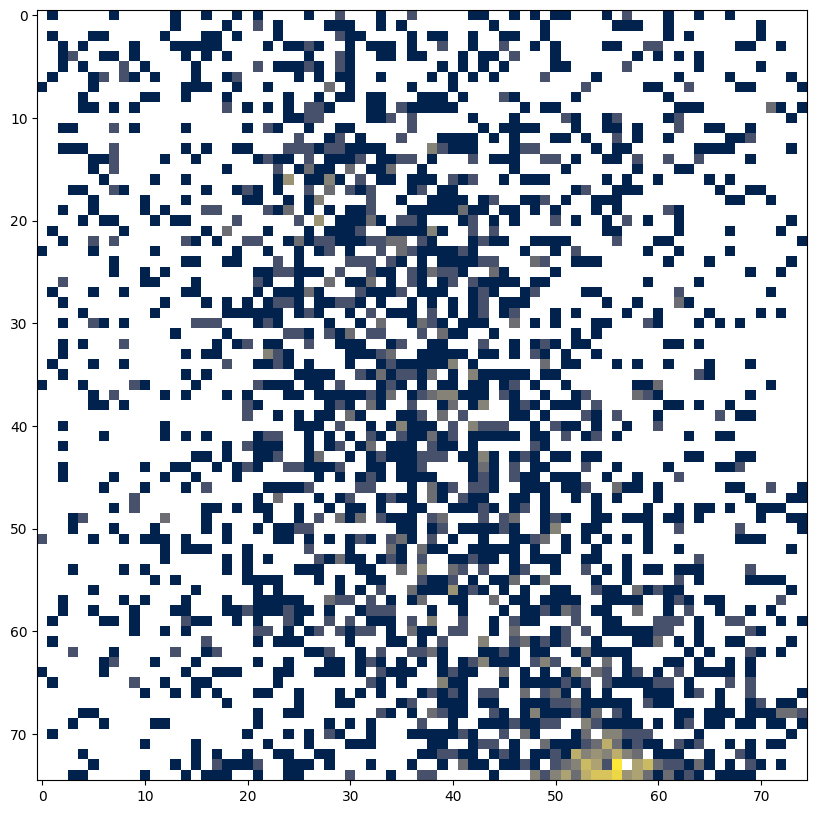

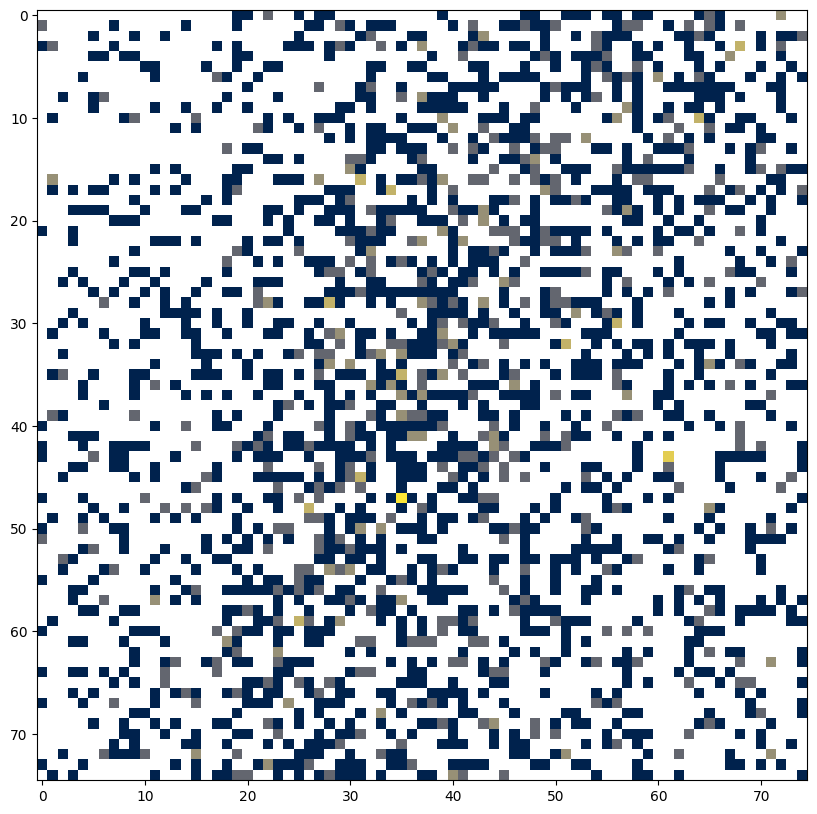

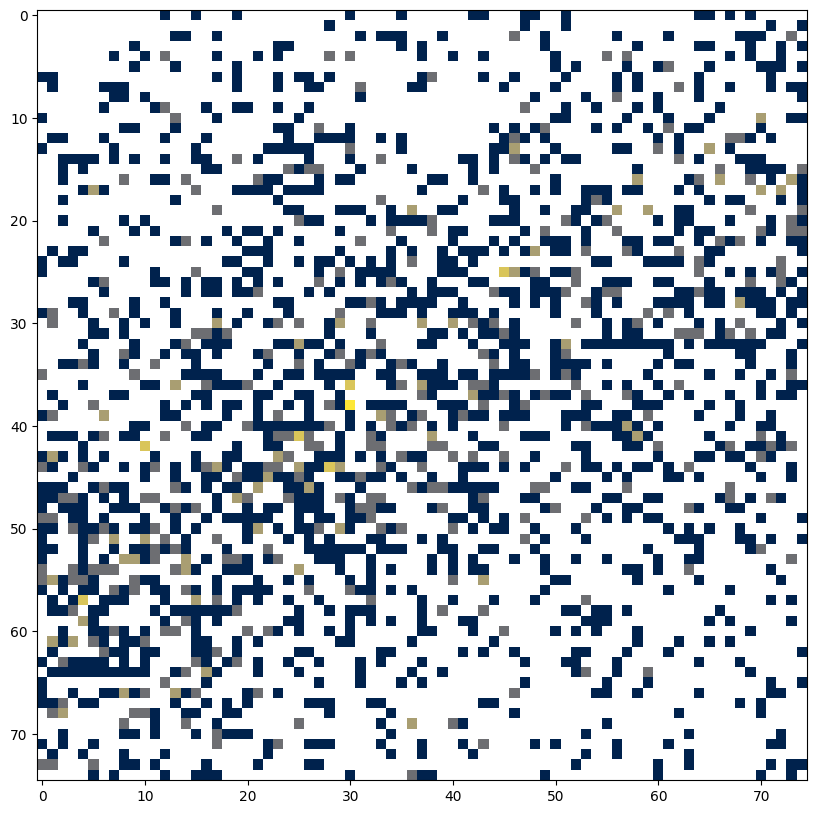

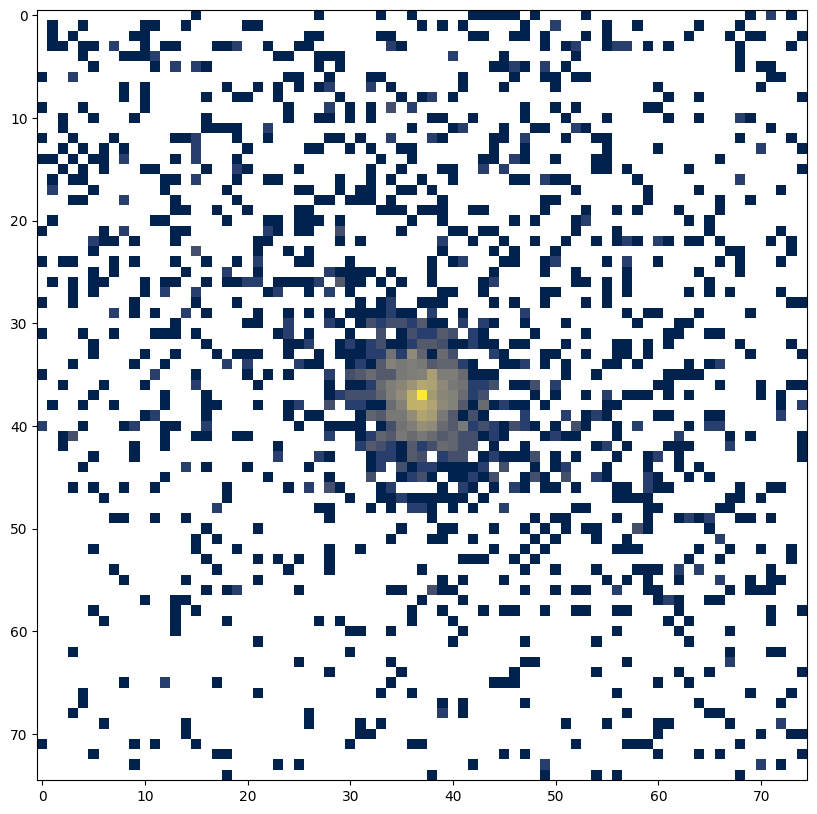

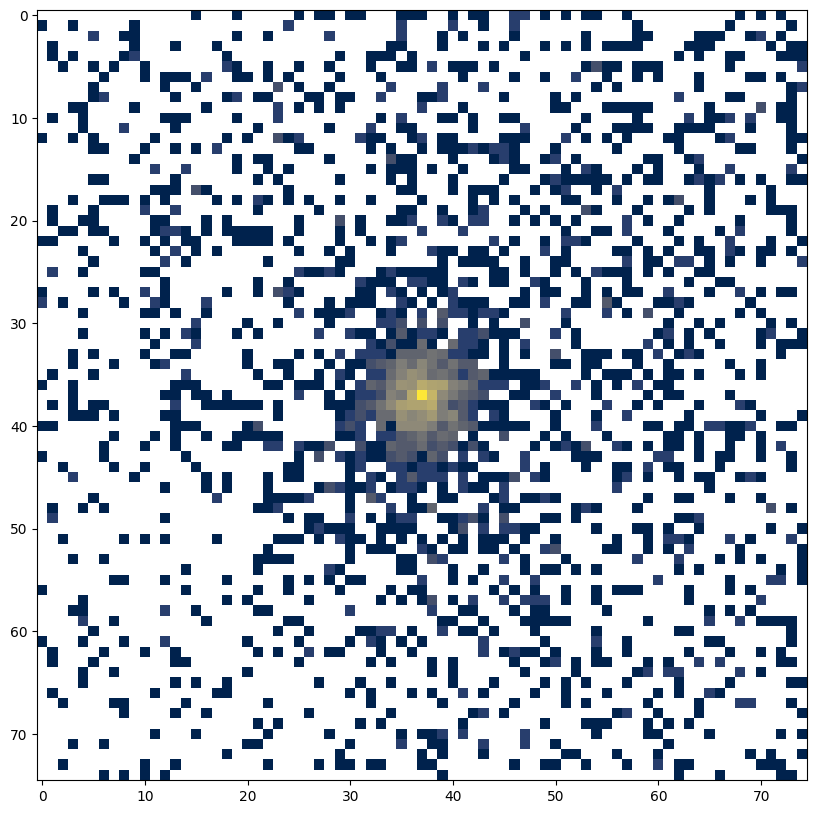

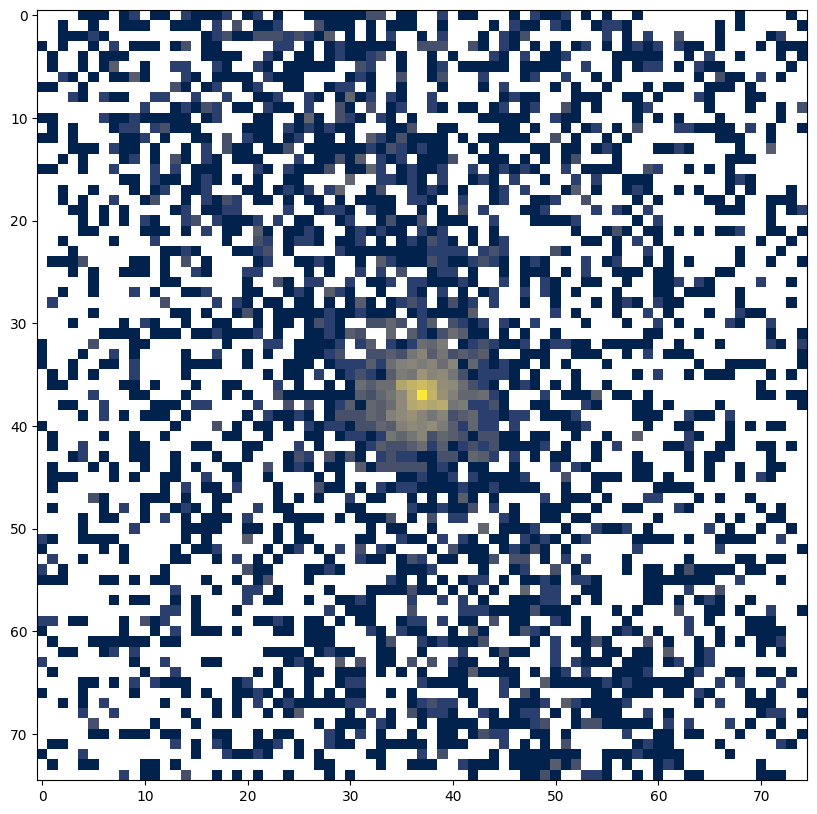

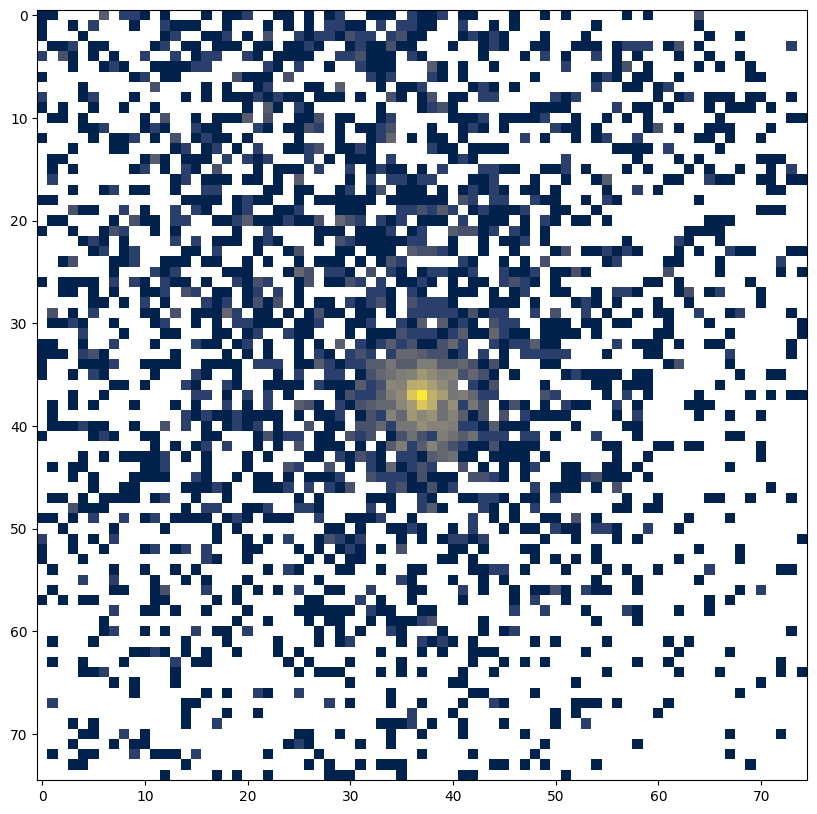

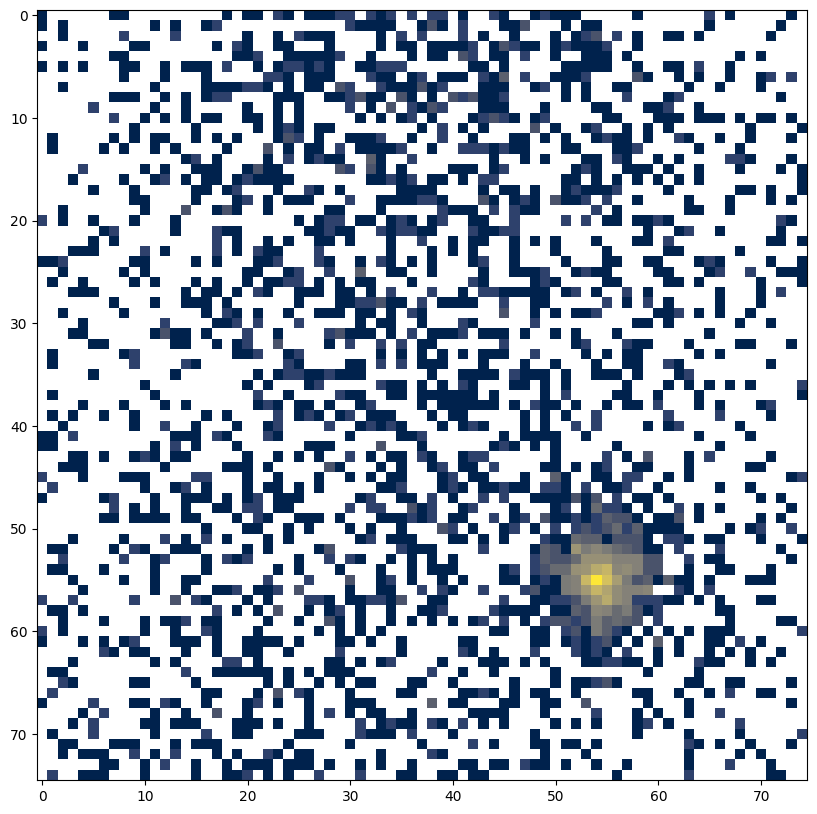

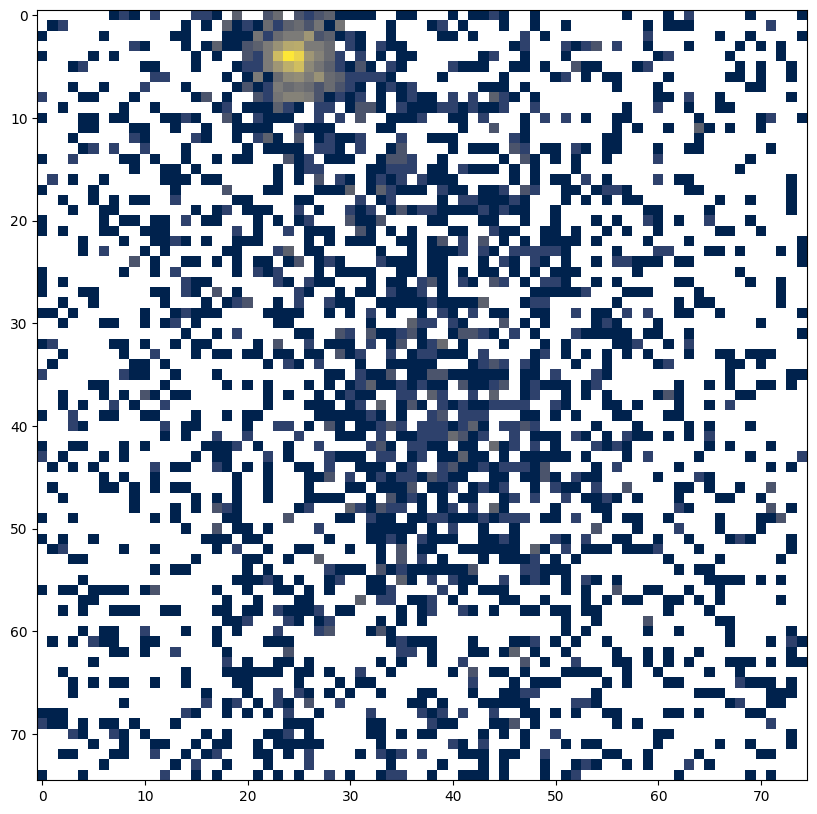

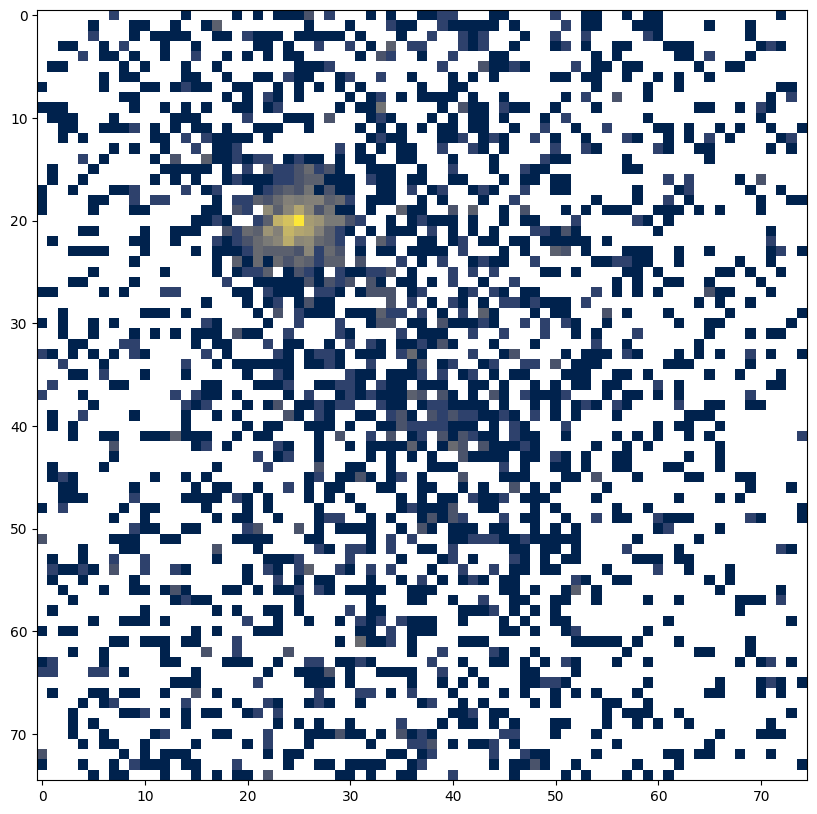

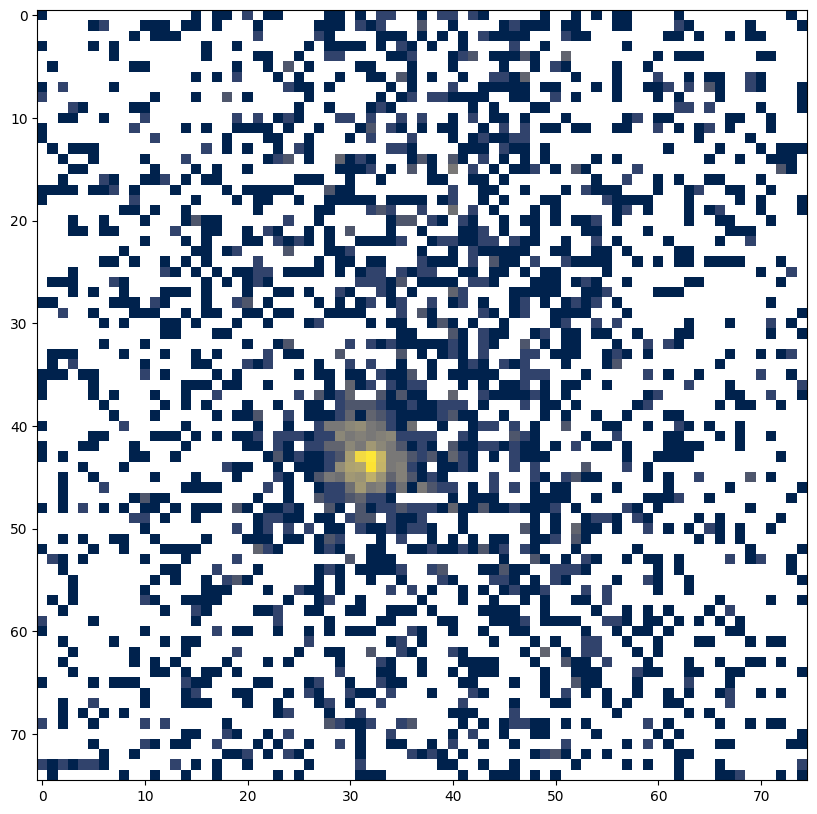

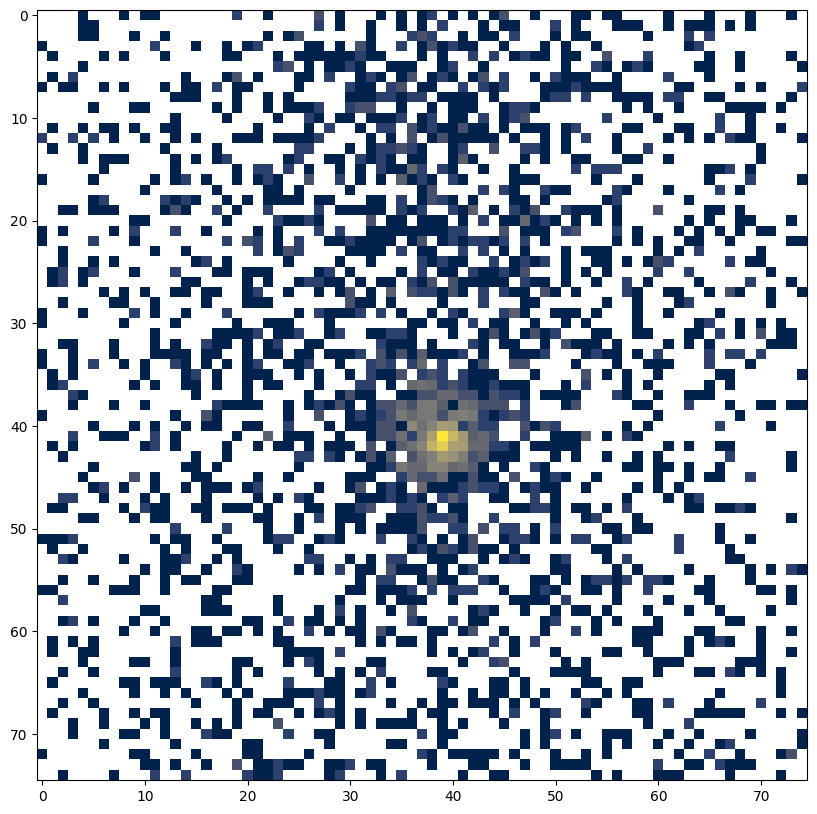

In [10]:
# Run ellipse fitting for x-z (02) projection
# Same as edge-on projection of M33 

table_info_02, fit_success_02 = RunEllipseFitting(0, 2)
SaveToTable(0, 2, table_info_02, fit_success_02);

### Note: At each snapshot, the actual ellipses plotted on top of the projection are saved to the directory /plots/01/projections/. The radial profile of the fitted ellipses are similarly saved to /plots/01/ellipses/.

In [3]:
def Triaxiality(r200_index):
    """
    Function that computes the triaxiality parameter of M33 across time
    T = (1 - b/a)/(1 - c/a)

    INPUTS:
        -r200_index (int): An index of 1 computes the triaxiality at R200, 2 computes it at R200/2, and 3 computes it at R200/4

    OUTPUT:
        - time_range (numpy array of floats): Snapshot times where ellipse fitting succeeded (in Gyr) 
        - T (numpy array of floats): Triaxiality parameter 
    """
    # Read in table information for each projection
    Halo_01 = np.genfromtxt('halo_evo_01.txt')
    Halo_02 = np.genfromtxt('halo_evo_02.txt')
    Halo_12 = np.genfromtxt('halo_evo_12.txt')
 
    # Find the snapshots where ellipse fitting was successful across all three projections
    common = np.intersect1d(np.intersect1d(Halo_01[:,0], Halo_02[:,0]), Halo_12[:,0])

    # Mask the snapshots where not all three projections succeeded
    mask_01 = np.isin(Halo_01[:,0], common)
    mask_02 = np.isin(Halo_02[:,0], common)
    mask_12 = np.isin(Halo_12[:,0], common)

    # Calculate axis ratios from the ellipticity values 
    ar_01 = 1 - Halo_01[:, r200_index][mask_01]
    ar_02 = 1 - Halo_02[:, r200_index][mask_02]
    ar_12 = 1 - Halo_12[:, r200_index][mask_12]


    b_over_a = np.maximum(np.maximum(ar_01, ar_02), ar_12) # Uses projection with maximum axis ratio as b/a
    c_over_a = np.minimum(np.minimum(ar_01, ar_02), ar_12) # Uses projection with minimum axis ratio as c/a

    # Calculate triaxiality parameter 
    T = (1 - (b_over_a)**2)/(1 - (c_over_a)**2)

    # Convert time values from Myr to Gyr 
    time_range = Halo_01[:,0][mask_01]/1000

    # Return time_range, T
    return time_range, T

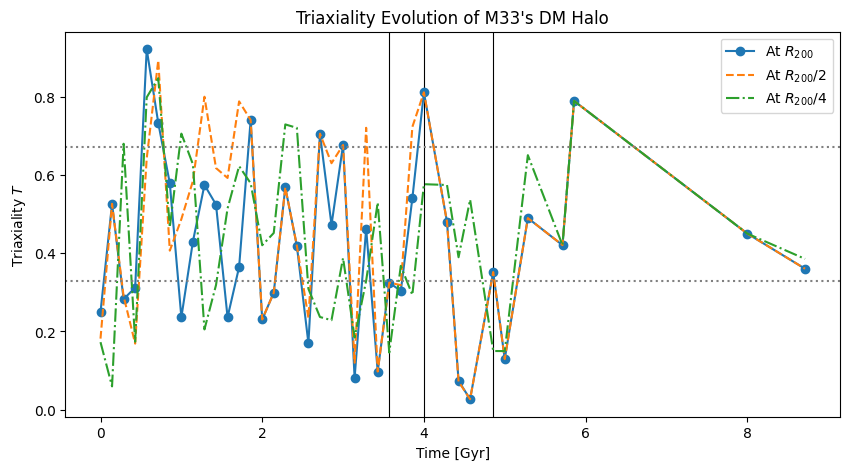

In [5]:
# Plot #1: Triaxiality plotted versus time (in Gyr) at R200, R200/2, and R200/4

# Retrieve ellipse information from .txt files and compute triaxiality 
T_R200 = Triaxiality(1)
T_R200d2 = Triaxiality(2)
T_R200d4 = Triaxiality(3)

plt.figure(figsize=(10,5))

# These three lines correspond to the time snapshots in the plot in the next cell (see next cell)
plt.axvline(3.57, c='k', linestyle='-', linewidth=0.8) 
plt.axvline(4.0, c='k', linestyle='-', linewidth=0.8)
plt.axvline(4.86, c='k', linestyle='-', linewidth=0.8)

# Plot triaxiality at each distance 
plt.plot(T_R200[0], T_R200[1], label=r'At $R_{200}$', marker='o')
plt.plot(T_R200d2[0], T_R200d2[1], linestyle='--', label=r'At $R_{200}/2$')
plt.plot(T_R200d4[0], T_R200d4[1], linestyle='-.', label=r'At $R_{200}/4$')

# In N.Garavito-Camargo et al. (2021), prolate, oblate, and triaxial are defined by 
# Prolate: T >= 0.67
# Oblate: T <= 0.33
# Triaxial: 0.67 > T > 0.33

plt.axhline(0.33, c='gray', linestyle=':') # Oblate/triaxial boundary
plt.axhline(0.67, c='gray', linestyle=':') # Prolate/triaxial boundary

plt.legend()

# Set axis and title labels 
plt.ylabel('Triaxiality $T$')
plt.xlabel('Time [Gyr]')
plt.title("Triaxiality Evolution of M33's DM Halo")

# Save figure to pdf to use in report
plt.savefig('Triaxiality_Evo.pdf', bbox_inches='tight')

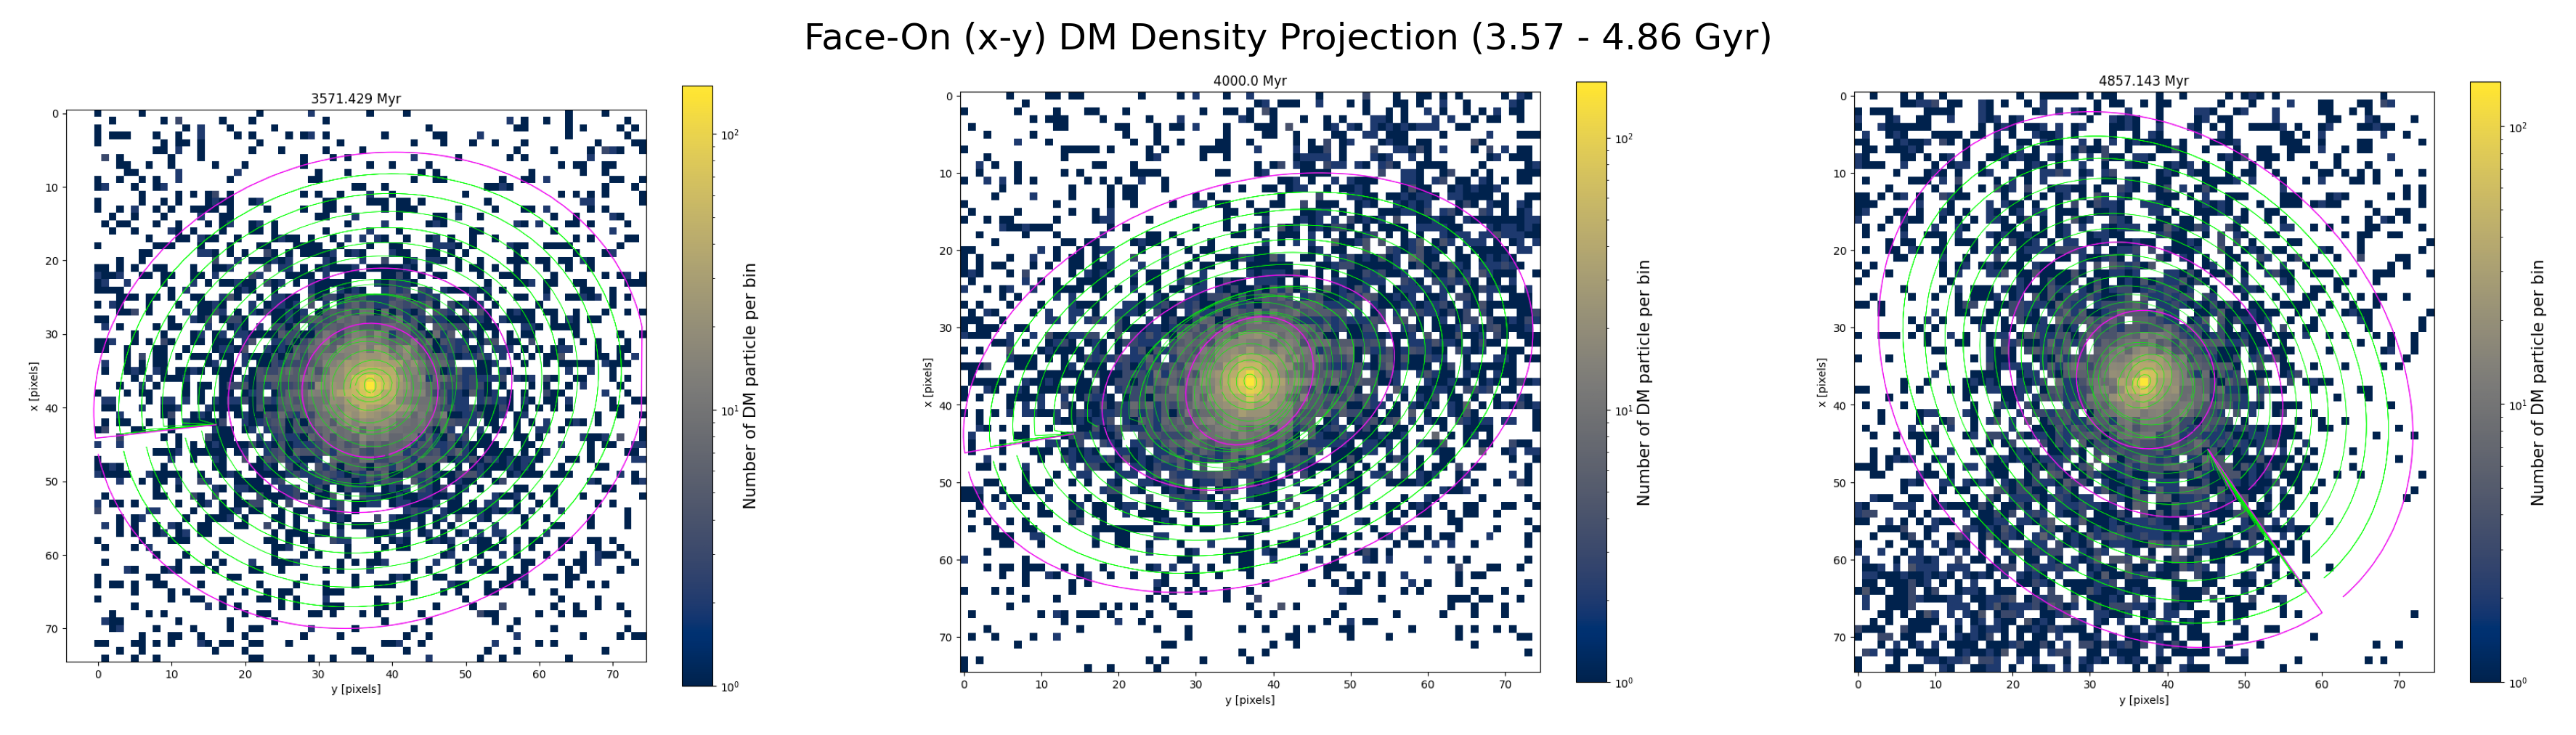

In [4]:
# Plot face-on projections near 4 Gyr (snapshot 280) to see changes due to merger

snap_250 = mpimg.imread('./plots/01/projections/M33_250.png')
snap_280 = mpimg.imread('./plots/01/projections/M33_280.png')
snap_340 = mpimg.imread('./plots/01/projections/M33_340.png')

fig, ax = plt.subplots(1, 3, figsize=(15,5), dpi=300)

# Plot projection for snapshot 250 (3.57 Gyr)
ax[0].imshow(snap_250)
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

# Remove outer border of image box
for spine in ax[0].spines.values():
    spine.set_visible(False)

# Plot projection for snapshot 280 (4 Gyr)
ax[1].imshow(snap_280)
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

# Remove outer border of image box
for spine in ax[1].spines.values():
    spine.set_visible(False)

# Plot projection for snapshot 340 (4.86 Gyr)
ax[2].imshow(snap_340)
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

# Remove outer border of image box
for spine in ax[2].spines.values():
    spine.set_visible(False)

# Use middle axis to make title for entire figure 
ax[1].set_title('Face-On (x-y) DM Density Projection (3.57 - 4.86 Gyr)')

# Save figure to pdf for report 
fig.savefig('XY_Evo_NearMerger.pdf', bbox_inches='tight')